# Integrantes:
- Carlo Reyes Espinoza.
- Ignacia Reyes Espinoza.

# Docente:
- Marcelo Tapia Contreras.


# **Modelos del lenguaje con RNNs**
En esta parte, vamos a entrenar un modelo del lenguaje basado en caracteres con Recurrent Neural Networks. Asimismo, utilizaremos el modelo para generar texto. En particular, alimentaremos nuestro modelo con obras de la literatura clásica en castellano para obtener una red neuronal que sea capaz de "escribir" fragmentos literarios.

Los entrenamientos para obtener un modelo de calidad podrían tomar cierto tiempo (5-10 minutos por epoch), por lo que se aconseja empezar a trabajar pronto. El uso de GPUs no ayuda tanto con LSTMs como con CNNs, por lo que si tenéis máquinas potentes en casa es posible que podáis entrenar más rápido o a la misma velocidad que en Colab. En todo caso, la potencia de Colab es más que suficiente para completar esta actividad con éxito.

<center><img src="https://upload.wikimedia.org/wikipedia/commons/d/d8/El_ingenioso_hidalgo_don_Quijote_de_la_Mancha.jpg" style="text-align: center" height="300px"></center>

El dataset a utilizar consistirá en un archivo de texto con el contenido íntegro en castellano antiguo de El Ingenioso Hidalgo Don Quijote de la Mancha, disponible de manera libre en la página de [Project Gutenberg](https://www.gutenberg.org). Asimismo, como apartado optativo en este laboratorio se pueden utilizar otras fuentes de texto. Aquí podéis descargar los datos a utilizar de El Quijote y un par de obras adicionales:

[El ingenioso hidalgo Don Quijote de la Mancha (Miguel de Cervantes)](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219424&authkey=AH0gb-qSo5Xd7Io)

[Compilación de obras teatrales (Calderón de la Barca)](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219433&authkey=AKvGD6DC3IRBqmc)

[Trafalgar (Benito Pérez Galdós)](https://onedrive.live.com/download?cid=C506CF0A4F373B0F&resid=C506CF0A4F373B0F%219434&authkey=AErPCAtMKOI5tYQ)

Como ya deberíamos de estar acostumbrados en problemas de Machine Learning, es importante echar un vistazo a los datos antes de empezar.

#**1. Carga y procesado del texto.**

Primero, vamos a descargar el libro e inspeccionar los datos. El fichero a descargar es una versión en .txt del libro de Don Quijote, a la cual se le han borrado introducciones, licencias y otras secciones para dejarlo con el contenido real de la novela.

In [1]:
import random
import io
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.callbacks import LambdaCallback
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, LSTM, GRU, Embedding

%matplotlib inline

path = "/content/Don Quijote de la Mancha.txt"

Una vez descargado, vamos a leer el contenido del fichero en una variable. Adicionalmente, convertiremos el contenido del texto a minúsculas para ponérselo un poco más fácil a nuestro modelo (de modo que todas las letras sean minúsculas y el modelo no necesite diferenciar entre minúsculas y mayúsculas).

## 1.1. Leer todo el contenido del fichero en una única variable ***text*** y convertir el string a minúsculas.

In [2]:
# Leemos el archivo completo:
with open(path, "r", encoding="utf-8") as f:
    text = f.read().lower()

print("Texto cargado correctamente.")
print("Longitud del texto:", len(text))
print(text[:1000])

Texto cargado correctamente.
Longitud del texto: 2071198
capítulo primero. que trata de la condición y ejercicio del famoso hidalgo
don quijote de la mancha


en un lugar de la mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. una olla de algo más vaca que carnero,
salpicón las más noches, duelos y quebrantos los sábados, lantejas los
viernes, algún palomino de añadidura los domingos, consumían las tres
partes de su hacienda. el resto della concluían sayo de velarte, calzas de
velludo para las fiestas, con sus pantuflos de lo mesmo, y los días de
entresemana se honraba con su vellorí de lo más fino. tenía en su casa una
ama que pasaba de los cuarenta, y una sobrina que no llegaba a los veinte,
y un mozo de campo y plaza, que así ensillaba el rocín como tomaba la
podadera. frisaba la edad de nuestro hidalgo con los cincuenta años; era de
complexión recia, seco de carnes, enjuto 

Podemos comprobar ahora que efectivamente nuestra variable contiene el resultado deseado, con el comienzo tan característico del Quijote.

In [3]:
print("Longitud del texto: {}".format(len(text)))
print(text[0:300])

Longitud del texto: 2071198
capítulo primero. que trata de la condición y ejercicio del famoso hidalgo
don quijote de la mancha


en un lugar de la mancha, de cuyo nombre no quiero acordarme, no ha mucho
tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua,
rocín flaco y galgo corredor. una olla de algo más


#**2. Procesado de los datos.**

Una de las grandes ventajas de trabajar con modelos que utilizan caracteres en vez de palabras es que no necesitamos tokenizar el texto (partirlo palabra a palabra). Nuestro modelo funcionará directamente con los caracteres en el texto, incluyendo espacios, saltos de línea, etc.

Antes de hacer nada, necesitamos procesar el texto en entradas y salidas compatibles con nuestro modelo. Como sabemos, un modelo del lenguaje con RNNs acepta una serie de caracteres y predice el siguiente carácter en la secuencia.

* "*El ingenioso don Qui*" -> predicción: **j**
* "*El ingenioso don Quij*" -> predicción: **o**

De modo que la entrada y la salida de nuestro modelo necesita ser algo parecido a este esquema. En este punto, podríamos usar dos formas de preparar los datos para nuestro modelo.

1. **Secuencia a secuencia**. La entrada de nuestro modelo sería una secuencia y la salida sería esa secuencia trasladada un caracter a la derecha, de modo que en cada instante de tiempo la RNN tiene que predecir el carácter siguiente. Por ejemplo:

>* *Input*:   El ingenioso don Quijot
>* *Output*: l ingenioso don Quijote

2. **Secuencia a carácter**. En este variante, pasaríamos una secuencia de caracteres por nuestra RNN y, al llegar al final de la secuencia, predeciríamos el siguiente carácter.

>* *Input*:   El ingenioso don Quijot
>* *Output*: e

En este laboratorio, por simplicidad, vamos a utilizar la segunda variante.

De este modo, a partir del texto, hemos de generar nuestro propio training data que consista en secuencias de caracteres con el siguiente carácter a predecir. Para estandarizar las cosas, utilizaremos secuencias de tamaño *SEQ_LENGTH* caracteres (un hiperparámetro que podemos elegir nosotros).



## 2.1. Obtención de los caracteres y mapas de caracteres.

Antes que nada, necesitamos saber qué caracteres aparecen en el texto, ya que tendremos que diferenciarlos mediante un índice de 0 a *num_chars* - 1 en el modelo. Obtener:


1.   Número de caracteres únicos que aparecen en el texto.
2.   Diccionario que asocia char a índice único entre 0 y *num_chars* - 1. Por ejemplo, {'a': 0, 'b': 1, ...}
3.   Diccionario reverso de índices a caracteres: {0: 'a', 1: 'b', ...}


In [4]:
# Obtenemos los caracteres únicos presentes en el texto:
chars = sorted(list(set(text)))

NUM_CHARS = len(chars)

# Diccionario de carácter a índice:
char_to_indices = {char: i for i, char in enumerate(chars)}

# Diccionario de índice a carácter:
indices_to_char = {i: char for i, char in enumerate(chars)}

print("Número de caracteres únicos:", NUM_CHARS)
print("Primeros caracteres:", chars[:50])
print("Ejemplo char_to_indices:", list(char_to_indices.items())[:10])
print("Ejemplo indices_to_char:", list(indices_to_char.items())[:10])

Número de caracteres únicos: 61
Primeros caracteres: ['\n', ' ', '!', '"', "'", '(', ')', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', ':', ';', '?', ']', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '¡', '«', '»']
Ejemplo char_to_indices: [('\n', 0), (' ', 1), ('!', 2), ('"', 3), ("'", 4), ('(', 5), (')', 6), (',', 7), ('-', 8), ('.', 9)]
Ejemplo indices_to_char: [(0, '\n'), (1, ' '), (2, '!'), (3, '"'), (4, "'"), (5, '('), (6, ')'), (7, ','), (8, '-'), (9, '.')]


## 2.2. Obtención de secuencias de entrada y carácter a predecir.

Ahora, vamos a obtener las secuencias de entrada en formato texto y los correspondientes caracteres a predecir. Para ello, recorrer el texto completo leído anteriormente, obteniendo una secuencia de SEQ_LENGTH caracteres y el siguiente caracter a predecir. Una vez hecho, desplazarse un carácter a la izquierda y hacer lo mismo para obtener una nueva secuencia y predicción. Guardar las secuencias en una variable ***sequences*** y los caracteres a predecir en una variable ***next_chars***.

Por ejemplo, si el texto fuera "Don Quijote" y SEQ_LENGTH fuese 5, tendríamos

* *sequences* = ["Don Q", "on Qu", "n Qui", " Quij", "Quijo", "uijot"]
* *next_chars* = ['u', 'i', 'j', 'o', 't', 'e']

In [5]:
# Definimos el tamaño de las secuencias. Puedes dejar este valor por defecto.
SEQ_LENGTH = 30

sequences = []
next_chars = []

## TU CÓDIGO AQUÍ

# Creamos secuencias de largo SEQ_LENGTH y su carácter siguiente:

for i in range(0, len(text) - SEQ_LENGTH):
    sequences.append(text[i:i + SEQ_LENGTH])
    next_chars.append(text[i + SEQ_LENGTH])

print("Número de secuencias generadas:", len(sequences))
print("Ejemplo de secuencia:", sequences[0])
print("Carácter a predecir:", next_chars[0])

Número de secuencias generadas: 2071168
Ejemplo de secuencia: capítulo primero. que trata de
Carácter a predecir:  


Indicar el tamaño del training set que acabamos de generar.

In [6]:
print("Tamaño del training set:", len(sequences))
print("Cantidad de caracteres objetivo:", len(next_chars))

Tamaño del training set: 2071168
Cantidad de caracteres objetivo: 2071168


Como el Quijote es muy largo y tenemos muchas secuencias, podríamos encontrar problemas de memoria. Por ello, vamos a elegir un número máximo de ellas. Si estás corriendo esto localmente y tienes problemas de memoria, puedes reducir el tamaño aún más, pero ten cuidado porque, a menos datos, peor calidad del modelo.

In [7]:
MAX_SEQUENCES = 500000

perm = np.random.permutation(len(sequences))
sequences, next_chars = np.array(sequences), np.array(next_chars)
sequences, next_chars = sequences[perm], next_chars[perm]
sequences, next_chars = list(sequences[:MAX_SEQUENCES]), list(next_chars[:MAX_SEQUENCES])

print(len(sequences))

500000


## 2.3. Obtención de input X y output y para el modelo.

Finalmente, a partir de los datos de entrenamiento que hemos generado vamos a crear los arrays de datos X e y que pasaremos a nuestro modelo.

Para ello, vamos a utilizar *one-hot encoding* para nuestros caracteres. Por ejemplo, si sólo tuviéramos 4 caracteres (a, b, c, d), las representaciones serían: (1, 0, 0, 0), (0, 1, 0, 0), (0, 0, 1, 0) y (0, 0, 0, 1).

De este modo, **X** tendrá shape *(num_sequences, seq_length, num_chars)* e **y** tendrá shape *(num_sequences, num_chars)*.



In [8]:
NUM_CHARS = len(chars)
NUM_SEQUENCES = len(sequences)

# Usamos bool para ahorrar memoria:
X = np.zeros((NUM_SEQUENCES, SEQ_LENGTH, NUM_CHARS), dtype=np.bool_)
y = np.zeros((NUM_SEQUENCES, NUM_CHARS), dtype=np.bool_)

for i, sequence in enumerate(sequences):
    for t, char in enumerate(sequence):
        X[i, t, char_to_indices[char]] = 1

    y[i, char_to_indices[next_chars[i]]] = 1

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (500000, 30, 61)
Shape de y: (500000, 61)


#**3. Definición del modelo y entrenamiento.**

Una vez tenemos ya todo preparado, es hora de definir el modelo. Define un modelo que utilice una **LSTM** con **128 unidades internas**. Si bien el modelo puede definirse de una manera más compleja, para empezar debería bastar con una LSTM más una capa Dense con el *softmax* que predice el siguiente caracter a producir. Adam puede ser una buena elección de optimizador.

Una vez el modelo esté definido, entrénalo un poco para asegurarte de que la loss es decreciente. No es necesario guardar la salida de este entrenamiento en el entregable final, ya que vamos a hacer el entrenamiento más informativo en el siguiente punto.

In [9]:
model = Sequential()

model.add(LSTM(
    128,
    input_shape=(SEQ_LENGTH, NUM_CHARS)
))

model.add(Dense(NUM_CHARS, activation="softmax"))

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        97,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,149 (410.74 KB)

 Trainable params: 105,149 (410.74 KB)

 Non-trainable params: 0 (0.00 B)

Para ver cómo evoluciona nuestro modelo del lenguaje, vamos a generar texto según va entrenando. Para ello, vamos a programar una función que, utilizando el modelo en su estado actual, genere texto, con la idea de ver cómo se va generando texto al entrenar cada epoch.

En el código de abajo podemos ver una función auxiliar para obtener valores de una distribución multinomial. Esta función se usará para muestrear el siguiente carácter a utilizar según las probabilidades de la salida de softmax (en vez de tomar directamente el valor con la máxima probabilidad, obtenemos un valor aleatorio según la distribución de probabilidad dada por softmax, de modo que nuestros resultados serán más diversos, pero seguirán teniendo "sentido" ya que el modelo tenderá a seleccionar valores con más probabilidad).



In [10]:
def sample(probs, temperature=1.0):
    """Nos da el índice del elemento a elegir según la distribución
    de probabilidad dada por probs.

    Args:
      probs es la salida dada por una capa softmax:
        probs = model.predict(x_to_predict)[0]

      temperature es un parámetro que nos permite obtener mayor
        "diversidad" a la hora de obtener resultados.

        temperature = 1 nos da la distribución normal de softmax
        0 < temperature < 1 hace que el sampling sea más conservador,
          de modo que sampleamos cosas de las que estamos más seguros
        temperature > 1 hace que los samplings sean más atrevidos,
          eligiendo en más ocasiones clases con baja probabilidad.
          Con esto, tenemos mayor diversidad pero se cometen más
          errores.
    """
    # Cast a float64 por motivos numéricos:
    probs = np.asarray(probs).astype('float64')

    # Hacemos logaritmo de probabilidades y aplicamos reducción por temperatura:
    probs = np.log(probs) / temperature

    # Volvemos a aplicar exponencial y normalizamos de nuevo:
    exp_probs = np.exp(probs)
    probs = exp_probs / np.sum(exp_probs)

    # Hacemos el sampling dadas las nuevas probabilidades de salida:
    samples = np.random.multinomial(1, probs, 1)
    return np.argmax(samples)


Utilizando la función anterior y el modelo entrenado, vamos a añadir un callback a nuestro modelo para que, según vaya entrenando, veamos los valores que resultan de generar textos con distintas temperaturas al acabar cada epoch.

Para ello, abajo tenéis disponible el callback *on_epoch_end*. Esta función elige una secuencia de texto al azar en el texto disponible en la variable
text y genera textos de longitud *GENERATED_TEXT_LENGTH* según las temperaturas en *TEMPERATURES_TO_TRY*, utilizando para ello la función *generate_text*.

Completa la función *generate_text* de modo que utilicemos el modelo y la función sample para generar texto.

NOTA: Cuando hagas model.predict, es aconsejable usar verbose=0 como argumento para evitar que la función imprima valores de salida.

In [11]:
TEMPERATURES_TO_TRY = [0.2, 0.5, 1.0, 1.2]
GENERATED_TEXT_LENGTH = 300

def generate_text(seed_text, model, length, temperature=1):
    """Genera una secuencia de texto a partir de seed_text utilizando model.

    La secuencia tiene longitud length y el sampling se hace con la temperature
    definida.
    """

    # Aquí guardaremos nuestro texto generado, que incluirá el texto origen:
    generated = seed_text

    for i in range(length):

        # Tomamos los últimos SEQ_LENGTH caracteres generados:
        sentence = generated[-SEQ_LENGTH:]

        # Creamos el vector one-hot para predecir el siguiente carácter:
        X_pred = np.zeros((1, SEQ_LENGTH, NUM_CHARS), dtype=np.bool_)

        for t, char in enumerate(sentence):
            if char in char_to_indices:
                X_pred[0, t, char_to_indices[char]] = 1

        # Predicción del modelo:
        preds = model.predict(X_pred, verbose=0)[0]

        # Muestreo usando temperatura:
        next_index = sample(preds, temperature)
        next_char = indices_to_char[next_index]

        # Agregamos el carácter generado:
        generated += next_char

    return generated


def on_epoch_end(epoch, logs):
  print("\n\n\n")

  # Primero, seleccionamos una secuencia al azar para empezar a predecir a partir de ella:
  start_pos = random.randint(0, len(text) - SEQ_LENGTH - 1)
  seed_text = text[start_pos:start_pos + SEQ_LENGTH]
  for temperature in TEMPERATURES_TO_TRY:
    print("------> Epoch: {} - Generando texto con temperature {}".format(
        epoch + 1, temperature))

    generated_text = generate_text(seed_text, model,
                                   GENERATED_TEXT_LENGTH, temperature)
    print("Seed: {}".format(seed_text))
    print("Texto generado: {}".format(generated_text))
    print()


generation_callback = LambdaCallback(on_epoch_end=on_epoch_end)

Entrena ahora tu modelo. No te olvides de añadir *generation_callback* a la lista de callbacks utilizados en fit(). Ya que las métricas de clasificación no son tan críticas aquí (no nos importa tanto acertar el carácter exacto, sino obtener una distribución de probabilidad adecuada), no es necesario monitorizar la accuracy ni usar validation data, si bien puedes añadirlos para asegurarte de que todo está en orden.


In [12]:
generation_callback = LambdaCallback(on_epoch_end=on_epoch_end)

history = model.fit(
    X,
    y,
    batch_size=128,
    epochs=10,
    callbacks=[generation_callback]
)

Epoch 1/10
3897/3907 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.4345



------> Epoch: 1 - Generando texto con temperature 0.2
Seed: n venenos mortíferos, sino con
Texto generado: n venenos mortíferos, sino con en la de la de la habien de la me habar de la me habiendo la cuenta de la me haber si la caballa, y de la de la que la cabiendo de la caballa de la cuendo en la cama la manta de la me la de la habiento y alla de la mando el camo esta de la con esta la de la caballas de la caballa de la de la cante 

------> Epoch: 1 - Generando texto con temperature 0.5
Seed: n venenos mortíferos, sino con
Texto generado: n venenos mortíferos, sino con a cuas de sabía, a la sin el que sino esta la esa la canta de la de cuesto cancian que el suestra la señor el di fuero te a con an sal su la vienta y a man la la bien a cuende su para de la vuestro que la de su si le vienta la gueste mi hal a la las descuese en con que el como por se diera que lo s

------> Epoch: 1 - Generando texto con temperatu

## 3.1 Gráfico de pérdida de entrenamiento.

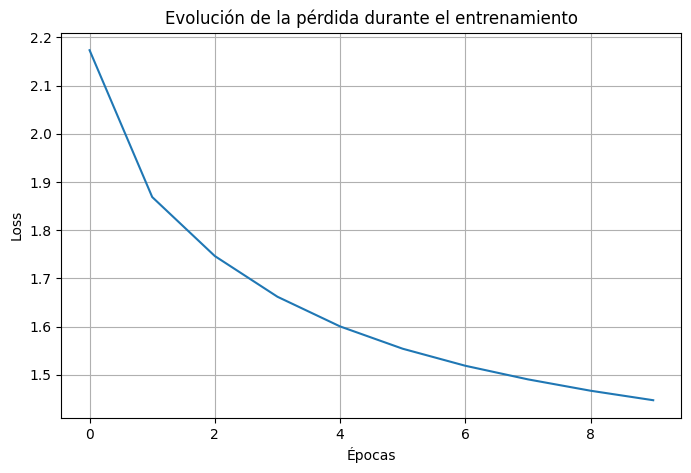

In [13]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"])
plt.title("Evolución de la pérdida durante el entrenamiento")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### **Análisis de la pérdida durante el entrenamiento:**

El gráfico muestra la evolución de la pérdida (`loss`) durante el entrenamiento del modelo LSTM.

Se observa que la pérdida disminuye progresivamente a medida que avanzan las épocas, comenzando aproximadamente sobre 2.18 y llegando a un valor cercano a 1.45 al finalizar el entrenamiento. Esto indica que el modelo está aprendiendo patrones del texto y mejora su capacidad para predecir el siguiente carácter.

La disminución de la pérdida es más marcada durante las primeras épocas, lo que significa que el modelo aprende rápidamente las relaciones más básicas del lenguaje, como la aparición de espacios, letras frecuentes y combinaciones comunes de caracteres.

En las últimas épocas la pérdida continúa bajando, pero de manera más lenta. Esto es esperable, ya que después de aprender patrones generales, el modelo necesita más entrenamiento para capturar estructuras más complejas del texto.

En conclusión, el comportamiento de la curva es positivo, ya que no se observan aumentos bruscos ni inestabilidad. Esto sugiere que el entrenamiento fue adecuado y que el modelo logró mejorar época a época.


## 3.2 Evaluación mediante métricas.

Además de analizar la pérdida del entrenamiento, se incorporan métricas de clasificación para evaluar el desempeño de los modelos.

Como el modelo trabaja a nivel de caracteres, la tarea se interpreta como una clasificación multiclase: a partir de una secuencia de entrada, el modelo debe predecir cuál será el siguiente carácter.

Las métricas utilizadas son:

- **Accuracy:** porcentaje de caracteres predichos correctamente.
- **Precision:** indica qué tan confiables son las predicciones del modelo para cada clase.
- **Recall:** indica qué proporción de caracteres reales fueron identificados correctamente.
- **F1-score:** combina precision y recall en una sola métrica.

Se utilizan métricas macro y weighted. Las métricas macro consideran todas las clases con el mismo peso, mientras que las weighted consideran la frecuencia de aparición de cada carácter.

## 3.3 Creación de funciones para evaluación mediante métricas.

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Cantidad de ejemplos para evaluar.
N_EVAL = 5000

def obtener_muestra(X_data, y_data, n=N_EVAL, seed=30):
    """
    Toma una muestra aleatoria del dataset para evaluar rápido
    sin tener que usar todos los datos.
    """
    n = min(n, len(X_data))
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(X_data), size=n, replace=False)
    return X_data[indices], y_data[indices]


def calcular_metricas(nombre_modelo, y_true, y_pred):
    """
    Calcula métricas de clasificación para predicción de caracteres.
    """
    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision Macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1-score Macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Precision Weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall Weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }


def evaluar_modelo_onehot(nombre_modelo, modelo, X_data, y_data, n=N_EVAL):
    """
    Evalúa modelos cuya entrada X está en one-hot encoding
    y cuya salida y también está en one-hot encoding.
    """
    X_eval, y_eval = obtener_muestra(X_data, y_data, n=n)

    y_true = np.argmax(y_eval, axis=1)

    y_pred_probs = modelo.predict(X_eval, batch_size=256, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    return calcular_metricas(nombre_modelo, y_true, y_pred)


def evaluar_modelo_sparse(nombre_modelo, modelo, X_data, y_data, n=N_EVAL):
    """
    Evalúa modelos cuya salida y está como índice entero.
    Sirve para modelos con Embedding.
    """
    X_eval, y_eval = obtener_muestra(X_data, y_data, n=n)

    y_true = y_eval

    y_pred_probs = modelo.predict(X_eval, batch_size=256, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    return calcular_metricas(nombre_modelo, y_true, y_pred)


def evaluar_modelo_seq2seq(nombre_modelo, modelo, X_data, y_data, n=2000):
    """
    Evalúa modelo secuencia a secuencia.
    Como predice una salida por cada posición temporal,
    se aplanan las predicciones y etiquetas reales.
    """
    X_eval, y_eval = obtener_muestra(X_data, y_data, n=n)

    y_pred_probs = modelo.predict(X_eval, batch_size=128, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=-1)

    y_true_flat = y_eval.reshape(-1)
    y_pred_flat = y_pred.reshape(-1)

    return calcular_metricas(nombre_modelo, y_true_flat, y_pred_flat)

## 3.4 Evaluación del modelo LSTM base.

In [55]:
modelo_lstm_base = model
history_lstm_base = history

print("Modelo LSTM base guardado con el nombre modelo_lstm_base")

Modelo LSTM base guardado con el nombre modelo_lstm_base


In [56]:
metricas_lstm_base = evaluar_modelo_onehot(
    nombre_modelo="LSTM base",
    modelo=modelo_lstm_base,
    X_data=X,
    y_data=y,
    n=N_EVAL
)

df_metricas_lstm_base = pd.DataFrame([metricas_lstm_base])

df_metricas_lstm_base.style \
    .format({
        "Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1-score Macro": "{:.4f}",
        "Precision Weighted": "{:.4f}",
        "Recall Weighted": "{:.4f}",
        "F1-score Weighted": "{:.4f}"
    }) \
    .hide(axis="index") \
    .set_caption("Métricas del modelo LSTM base")

Modelo,Accuracy,Precision Macro,Recall Macro,F1-score Macro,Precision Weighted,Recall Weighted,F1-score Weighted
LSTM base,0.5482,0.4113,0.3297,0.3431,0.5440,0.5482,0.5282


In [16]:
resultados_metricas_rnn = []

resultados_metricas_rnn.append(metricas_lstm_base)


## 3.5 Análisis de métricas del modelo LSTM base.

El modelo LSTM base obtuvo un accuracy de 0.5482, lo que significa que logró predecir correctamente aproximadamente el 54.82% de los caracteres evaluados.

Además, se obtuvo un F1-score weighted de 0.5282, lo que indica que el modelo tiene un desempeño razonable considerando la frecuencia real de aparición de los caracteres en el texto. Esta métrica es relevante porque en un corpus textual algunos caracteres aparecen mucho más que otros, por ejemplo espacios, vocales o consonantes comunes.

Por otro lado, las métricas macro fueron más bajas. El F1-score macro fue de 0.3431, con precision macro de 0.4113 y recall macro de 0.3297. Esto indica que el modelo tiene más dificultad para predecir correctamente caracteres menos frecuentes, como signos de puntuación, letras poco comunes o símbolos especiales.

Esta diferencia entre métricas macro y weighted es esperable en modelos de lenguaje a nivel de caracteres, ya que el dataset no está balanceado: algunos caracteres aparecen muchas veces y otros aparecen muy poco.

En conclusión, el modelo LSTM base logró aprender patrones generales del texto, pero todavía presenta limitaciones al predecir caracteres poco frecuentes. Por esta razón, se justifica comparar este modelo con otras configuraciones, como GRU, LSTM apilada, Embedding o cambios en `SEQ_LENGTH`, para analizar si las métricas mejoran.

## 3.5 Experimento de regularización: LSTM con Dropout y L2.

Luego de evaluar el modelo LSTM base, se incorpora un experimento de regularización utilizando Dropout y regularización L2.

El objetivo es analizar si estas técnicas ayudan a mejorar el desempeño del modelo o a controlar el sobreajuste. Dropout desactiva aleatoriamente una proporción de neuronas durante el entrenamiento, evitando que el modelo dependa demasiado de ciertas conexiones. La regularización L2 penaliza pesos demasiado grandes, favoreciendo un aprendizaje más general.

Este modelo se compara directamente con el LSTM base utilizando accuracy, precision, recall y F1-score.

In [85]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

modelo_lstm_dropout = Sequential()

modelo_lstm_dropout.add(LSTM(
    128,
    input_shape=(SEQ_LENGTH, NUM_CHARS),
    kernel_regularizer=l2(0.0001)
))

modelo_lstm_dropout.add(Dropout(0.3))

modelo_lstm_dropout.add(Dense(
    NUM_CHARS,
    activation="softmax"
))

modelo_lstm_dropout.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

history_lstm_dropout = modelo_lstm_dropout.fit(
    X,
    y,
    batch_size=128,
    epochs=10,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.3263 - loss: 2.2828
Epoch 2/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 43s 11ms/step - accuracy: 0.3930 - loss: 2.0205
Epoch 3/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 70s 8ms/step - accuracy: 0.4212 - loss: 1.9313
Epoch 4/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.4407 - loss: 1.8706
Epoch 5/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.4542 - loss: 1.8249
Epoch 6/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.4640 - loss: 1.7907
Epoch 7/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.4725 - loss: 1.7632
Epoch 8/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.4799 - loss: 1.7397
Epoch 9/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.4855 - loss: 1.7204
Epoch 10/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.4901 - loss: 1.7045


## 3.6 Evaluación del modelo base con Dropout.

In [86]:
metricas_lstm_dropout = evaluar_modelo_onehot(
    nombre_modelo="LSTM con Dropout + L2",
    modelo=modelo_lstm_dropout,
    X_data=X,
    y_data=y,
    n=N_EVAL
)

df_metricas_dropout = pd.DataFrame([
    metricas_lstm_base,
    metricas_lstm_dropout
])

df_metricas_dropout = df_metricas_dropout.sort_values(
    by="F1-score Weighted",
    ascending=False
)

df_metricas_dropout.style \
    .format({
        "Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1-score Macro": "{:.4f}",
        "Precision Weighted": "{:.4f}",
        "Recall Weighted": "{:.4f}",
        "F1-score Weighted": "{:.4f}"
    }) \
    .hide(axis="index") \
    .set_caption("Métricas comparativas: LSTM base vs LSTM con Dropout + L2")

Modelo,Accuracy,Precision Macro,Recall Macro,F1-score Macro,Precision Weighted,Recall Weighted,F1-score Weighted
LSTM base,0.5482,0.4113,0.3297,0.3431,0.5440,0.5482,0.5282
LSTM con Dropout + L2,0.5100,0.4017,0.2849,0.2951,0.5132,0.5100,0.4847


## 3.7 Gráfico comparativo.

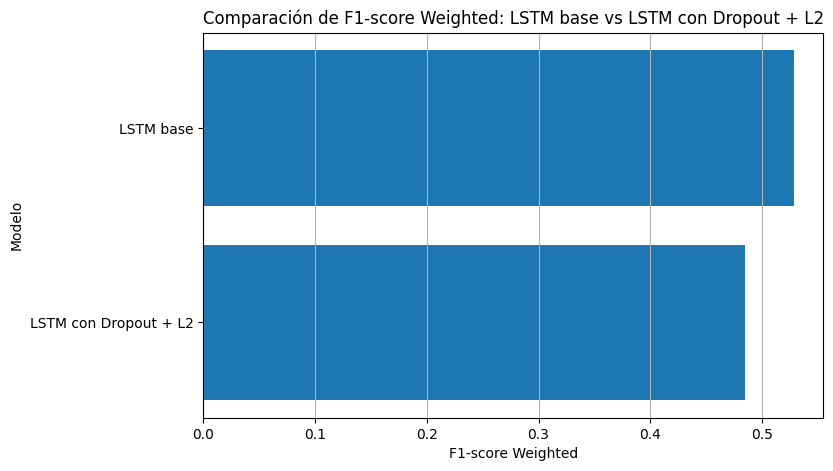

In [87]:
df_plot_dropout = df_metricas_dropout.sort_values(
    by="F1-score Weighted",
    ascending=True
)

plt.figure(figsize=(8,5))
plt.barh(
    df_plot_dropout["Modelo"],
    df_plot_dropout["F1-score Weighted"]
)

plt.title("Comparación de F1-score Weighted: LSTM base vs LSTM con Dropout + L2")
plt.xlabel("F1-score Weighted")
plt.ylabel("Modelo")
plt.grid(axis="x")
plt.show()

## 3.8 Análisis del experimento con Dropout y regularización L2.

En este experimento se comparó el modelo LSTM base con una variante regularizada mediante Dropout y regularización L2.

El objetivo de incorporar Dropout fue reducir la dependencia del modelo hacia ciertas conexiones internas, mientras que la regularización L2 buscó penalizar pesos demasiado grandes para evitar un ajuste excesivo al corpus de entrenamiento.

Según los resultados, el modelo LSTM base obtuvo mejores métricas que el modelo regularizado. El LSTM base alcanzó un accuracy de 0.5482 y un F1-score weighted de 0.5282, mientras que el modelo con Dropout + L2 obtuvo un accuracy de 0.5100 y un F1-score weighted de 0.4847.

Esto indica que, bajo esta configuración, la regularización no mejoró el desempeño del modelo. Aunque Dropout y L2 pueden ayudar a reducir el sobreajuste, también pueden dificultar el aprendizaje si el modelo todavía necesita mayor capacidad para capturar los patrones del texto.

En conclusión, este experimento permitió comprobar que la regularización no siempre mejora las métricas de forma directa. Para este caso, se mantiene el modelo LSTM base como mejor opción, ya que obtuvo mejores resultados en accuracy, precision, recall y F1-score.

---
---


## Entregable

Completa los apartados anteriores para entrenar modelos del lenguaje que sean capaces de generar texto con cierto sentido. Comentar los resultados obtenidos y cómo el modelo va mejorando época a época. Comentar las diferencias apreciadas al utilizar diferentes valores de temperatura. Entregar al menos la salida de un entrenamiento completo con los textos generados época a época.

El objetivo no es conseguir generar pasajes literarios con coherencia, sino obtener lenguaje que se asemeje en cierta manera a lo visto en el texto original y donde las palabras sean reconocibles como construcciones en castellano. Como ejemplo de lo que se puede conseguir, este es el resultado de generar texto después de 10 epochs y con temperature 0.2:


```
-----> Epoch: 10 - Generando texto con temperature 0.2
Seed: o le cautivaron y rindieron el
Texto generado: o le cautivaron y rindieron el caballero de la caballería de la mano de la caballería del cual se le dijo:

-¿quién es el verdad de la caballería de la caballería de la caballería de la caballería de la caballería, y me ha de habían de la mano que el caballero de la mano de la caballería. y que no se le habían de la mano de la c

```

Asimismo, se proponen los siguientes aspectos opcionales para conseguir nota extra:

*   Experimentar con los textos de teatro en verso de Calderón de la Barca (¿es capaz el modelo de aprender las estructuras del teatro en verso?) o con alguno de los otros textos disponibles. También se puede probar con textos de vuestra elección.
*   Experimentar con distintos valores de SEQ_LENGTH.
*   Experimentar con los hiperparámetros del modelo o probar otro tipo de modelos como GRUs o *stacked* RNNs (RNNs apiladas).
*   Experimentar utilizando embeddings en vez de representaciones one-hot.
*   (Difícil) Entrenar un modelo secuencia a secuencia en vez de secuencia a carácter.




#**4. Desarrollo de aspectos opcionales:**
A continuación, se desarrollarán los experimentos adicionales indicados de manera separada para poder analizar de mejor manera el comportamiento de cada uno de ellos.

## 4.1 Experimento con los textos de teatro en verso de Calderón de la Barca.

En este experimento se utiliza un texto de teatro de Pedro Calderón de la Barca para analizar si el modelo es capaz de aprender patrones distintos a los presentes en *Don Quijote de la Mancha*.

A diferencia de una novela, el teatro en verso presenta una estructura particular. Puede incluir nombres de personajes, intervenciones dialogadas, versos más breves, cambios de hablante y una organización más marcada por escenas o jornadas.

El objetivo de este experimento es observar si un modelo recurrente puede adaptarse a un corpus diferente y generar texto con características similares al teatro clásico en verso.

Para mantener una comparación justa con los experimentos anteriores, se utilizará una arquitectura LSTM similar, el mismo `SEQ_LENGTH`, el mismo batch size y la misma cantidad de épocas.

### 4.1.1 Carga del texto de Calderón.

El texto seleccionado corresponde a *Teatro selecto, tomo 1 de 4*, que contiene varias obras teatrales de Calderón. Esta elección permite trabajar con un corpus diferente al Quijote y evaluar si el modelo aprende patrones asociados al teatro.

In [17]:
import requests

url_calderon = "https://www.gutenberg.org/files/54436/54436-0.txt"

response = requests.get(url_calderon)
response.encoding = "utf-8"

text_calderon = response.text.lower()

print("Texto de Calderón descargado.")
print("Longitud inicial:", len(text_calderon))
print(text_calderon[:1000])

Texto de Calderón descargado.
Longitud inicial: 530335
*** start of the project gutenberg ebook 54436 ***

nota de transcripción

  * las cursivas se muestran entre _subrayados_ y las versalitas se
    han convertido a mayúsculas.

  * los errores de imprenta han sido corregidos sin avisar. para su
    detección se han tenido en cuenta otras ediciones de estos dramas.

  * se ha respetado la ortografía original, normalizándola a la
    grafía de mayor frecuencia. también se han respetado las
    inconsistencias en la acentuación.

  * no obstante, se han incorporado los siguientes cambios:

      p.  xvii: bolh de faber → böhl de faber
      p. xlvii:    copavacana → copacabana
      p.   335:    escena vi. → escena iv.

  * se han reparado los emparejamientos de los signos de admiración
    e interrogación.

  * las notas a pie de página se han renumerado y colocado tras el
    párrafo o la estrofa en que se encuentra la llamada.

  * en el original impreso, las indicaciones escénicas

### 4.1.2 Limpiar texto de Calderón.

El archivo descargado contiene encabezados, notas editoriales y secciones propias de Project Gutenberg. Por esta razón, se realiza una limpieza básica para trabajar principalmente con el contenido literario.

Además, se eliminan saltos de línea excesivos y se normalizan los espacios para facilitar el entrenamiento del modelo.

In [18]:
# Buscamos un punto de inicio más cercano al contenido teatral:
posibles_inicios = [
    "la vida es sueño",
    "jornada primera",
    "acto primero"
]

inicio = -1

for marcador in posibles_inicios:
    pos = text_calderon.find(marcador)
    if pos != -1:
        inicio = pos
        print("Inicio encontrado en:", marcador)
        break

if inicio != -1:
    text_calderon = text_calderon[inicio:]
else:
    print("No se encontró marcador de inicio. Se usará el texto completo.")

# Eliminamos posible pie de Gutenberg:
fin = text_calderon.find("*** end of the project gutenberg ebook")

if fin != -1:
    text_calderon = text_calderon[:fin]

# Limpieza básica:
text_calderon = text_calderon.replace("\r", " ")
text_calderon = text_calderon.replace("\n", " ")
text_calderon = " ".join(text_calderon.split())

print("Longitud final:", len(text_calderon))
print(text_calderon[:1000])

Inicio encontrado en: la vida es sueño
Longitud final: 461986
la vida es sueño. la devocion de la cruz. el mágico prodigioso. el príncipe constante. madrid luis navarro, editor colegiata, núm. 6 1881 estudio crítico. justa y noble cosa es que los pueblos honren la memoria de sus grandes poetas; pero si he de decir lo que siento, ántes me parece funesto que útil el entusiasmo oficial y la devocion obligada, que produce los aniversarios y centenarios, con el obligado cortejo de músicas, carros triunfales, pompas y apariencias, versos y justas poéticas. aun lo bueno sobre un mismo asunto empalaga, cuando es demasiado: ¿qué será cuando en la turbia corriente de tales solemnidades rueda tanto de mediano y áun de malo? la secta de los cervantistas acabaria, á no ser tan grande el personaje á quien injurian y apedrean, por hacer aborrecible hasta el nombre de cervántes en la memoria de las gentes. ¿quién sabe si conseguirán otro tanto los calderonianos, á fuerza de sacrificar en las aras de s

### 4.1.3 Caracteres y diccionarios del texto de Calderón.

Como el corpus de Calderón puede tener caracteres distintos al texto del Quijote, se crean nuevos diccionarios de caracteres.

Estos diccionarios permiten transformar cada carácter en un índice numérico y luego convertir las predicciones del modelo nuevamente a texto.

In [19]:
chars_calderon = sorted(list(set(text_calderon)))
NUM_CHARS_CALDERON = len(chars_calderon)

char_to_indices_calderon = {char: i for i, char in enumerate(chars_calderon)}
indices_to_char_calderon = {i: char for i, char in enumerate(chars_calderon)}

print("Número de caracteres únicos en Calderón:", NUM_CHARS_CALDERON)
print("Primeros caracteres:", chars_calderon[:50])

Número de caracteres únicos en Calderón: 69
Primeros caracteres: [' ', '!', '(', ')', '*', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', '}']


### 4.1.4 Creación de secuencias para Calderón.

El modelo se entrenará con un enfoque secuencia a carácter. Esto significa que recibirá una secuencia de caracteres y deberá predecir el carácter siguiente.

Se mantiene `SEQ_LENGTH = 30` para comparar este experimento con el modelo base entrenado sobre *Don Quijote de la Mancha*.

In [20]:
SEQ_LENGTH_CALDERON = 30
MAX_SEQUENCES_CALDERON = 100000
STEP_CALDERON = 3

def crear_dataset_calderon(texto, seq_length, chars, char_to_indices, max_sequences=100000, step=3):
    sequences = []
    next_chars = []

    for i in range(0, len(texto) - seq_length, step):
        sequences.append(texto[i:i + seq_length])
        next_chars.append(texto[i + seq_length])

        if len(sequences) >= max_sequences:
            break

    X_cald = np.zeros((len(sequences), seq_length, len(chars)), dtype=np.bool_)
    y_cald = np.zeros((len(sequences), len(chars)), dtype=np.bool_)

    for i, sequence in enumerate(sequences):
        for t, char in enumerate(sequence):
            X_cald[i, t, char_to_indices[char]] = 1

        y_cald[i, char_to_indices[next_chars[i]]] = 1

    return X_cald, y_cald, sequences, next_chars

In [21]:
X_calderon, y_calderon, sequences_calderon, next_chars_calderon = crear_dataset_calderon(
    texto=text_calderon,
    seq_length=SEQ_LENGTH_CALDERON,
    chars=chars_calderon,
    char_to_indices=char_to_indices_calderon,
    max_sequences=MAX_SEQUENCES_CALDERON,
    step=STEP_CALDERON
)

print("Shape X_calderon:", X_calderon.shape)
print("Shape y_calderon:", y_calderon.shape)

print("\nEjemplo de secuencia:")
print(sequences_calderon[0])

print("\nCarácter siguiente:")
print(next_chars_calderon[0])

Shape X_calderon: (100000, 30, 69)
Shape y_calderon: (100000, 69)

Ejemplo de secuencia:
la vida es sueño. la devocion 

Carácter siguiente:
d


### 4.1.5 Definición del modelo para Calderón.

Se utiliza una arquitectura LSTM similar a la usada con el Quijote, para que la comparación se centre principalmente en el cambio de corpus.

La capa LSTM contiene 128 unidades, ya que este valor ofrece una capacidad suficiente para aprender patrones de secuencias sin aumentar demasiado el costo computacional.

La capa final utiliza `softmax`, porque el modelo debe escoger el carácter más probable entre todos los caracteres únicos del texto de Calderón.

In [22]:
def crear_modelo_calderon(seq_length, num_chars):
    model_calderon = Sequential()

    model_calderon.add(LSTM(
        128,
        input_shape=(seq_length, num_chars)
    ))

    model_calderon.add(Dense(num_chars, activation="softmax"))

    model_calderon.compile(
        loss="categorical_crossentropy",
        optimizer="adam"
    )

    return model_calderon

In [23]:
modelo_calderon = crear_modelo_calderon(
    seq_length=SEQ_LENGTH_CALDERON,
    num_chars=NUM_CHARS_CALDERON
)

modelo_calderon.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │       101,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 69)             │         8,901 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,277 (430.77 KB)

 Trainable params: 110,277 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

### 4.1.6 Entrenamiento del modelo con Calderón.

El modelo se entrena durante 10 épocas, manteniendo el batch size en 128 para conservar una configuración similar al modelo base.

El objetivo no es obtener una generación literaria perfecta, sino observar si el modelo logra aprender patrones básicos del teatro en verso, como palabras reconocibles, estructuras de diálogo o secuencias similares al corpus teatral.

In [24]:
EPOCHS_CALDERON = 10
BATCH_SIZE_CALDERON = 128

history_calderon = modelo_calderon.fit(
    X_calderon,
    y_calderon,
    batch_size=BATCH_SIZE_CALDERON,
    epochs=EPOCHS_CALDERON,
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 2.6694
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2.2610
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2.1656
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 2.1067
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2.0636
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.0285
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.9969
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 1.9679
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 1.9410
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 1.9155


### 4.1.7 Gráfico de pérdida.

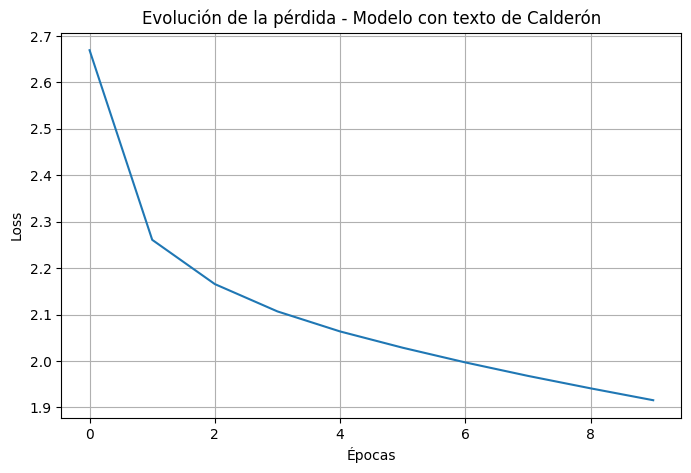

In [25]:
plt.figure(figsize=(8,5))
plt.plot(history_calderon.history["loss"])
plt.title("Evolución de la pérdida - Modelo con texto de Calderón")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Análisis de la pérdida del modelo con texto de Calderón.

El gráfico muestra la evolución de la pérdida durante el entrenamiento del modelo LSTM utilizando textos de teatro en verso de Calderón de la Barca.

Se observa que la pérdida disminuye de forma progresiva a medida que avanzan las épocas, comenzando aproximadamente en 2.70 y finalizando cerca de 1.90. Esta disminución indica que el modelo logró aprender patrones del corpus y mejorar su capacidad para predecir el siguiente carácter.

La caída más fuerte ocurre durante las primeras épocas, especialmente entre la época 0 y la época 1. Esto sugiere que el modelo aprende rápidamente patrones básicos del texto, como combinaciones frecuentes de letras, espacios y estructuras comunes del lenguaje.

En las épocas posteriores, la pérdida continúa bajando, pero de manera más lenta. Esto es esperable, ya que después de aprender patrones básicos, el modelo necesita más entrenamiento para capturar estructuras más complejas del teatro en verso.

Aunque la pérdida final sigue siendo relativamente alta en comparación con otros experimentos, el comportamiento de la curva es positivo porque no presenta aumentos bruscos ni inestabilidad. Esto indica que el modelo sí está aprendiendo, pero que el corpus de Calderón puede ser más difícil de modelar debido a su estructura teatral, presencia de diálogos, versos, nombres de personajes y cambios de intervención.

En conclusión, el modelo logró aprender patrones generales del texto de Calderón, aunque probablemente necesitaría más épocas, más datos o una arquitectura más compleja para generar texto con mayor coherencia.

### 4.1.8 Generación de texto con el modelo de Calderón.

Para generar texto con el modelo entrenado sobre Calderón, se utiliza una semilla inicial y se predice carácter por carácter.

Se generan textos con distintas temperaturas para observar cómo cambia la estabilidad y creatividad del modelo.

In [26]:
def sample_calderon(preds, temperature=1.0):
    preds = np.asarray(preds).astype("float64")
    preds = np.log(preds + 1e-8) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)

    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

In [27]:
def generate_text_calderon(seed_text, model, length, temperature=1.0):
    generated = seed_text.lower()

    if len(generated) < SEQ_LENGTH_CALDERON:
        generated = generated.rjust(SEQ_LENGTH_CALDERON)

    for i in range(length):
        sentence = generated[-SEQ_LENGTH_CALDERON:]

        X_pred = np.zeros((1, SEQ_LENGTH_CALDERON, NUM_CHARS_CALDERON), dtype=np.bool_)

        for t, char in enumerate(sentence):
            if char in char_to_indices_calderon:
                X_pred[0, t, char_to_indices_calderon[char]] = 1

        preds = model.predict(X_pred, verbose=0)[0]

        next_index = sample_calderon(preds, temperature)
        next_char = indices_to_char_calderon[next_index]

        generated += next_char

    return generated

### 4.1.9 Generación con distintas temperaturas.

Se entrenará el modelo con las siguientes temperaturas para visualizar su comportamiento:
- 0.2
- 0.5
- 1.0
- 1.2

In [28]:
seed_calderon = "jornada primera"

for temp in [0.2, 0.5, 1.0, 1.2]:
    print("\n" + "="*80)
    print(f"Texto generado con Calderón - Temperatura {temp}")
    print("="*80)

    texto_generado = generate_text_calderon(
        seed_text=seed_calderon,
        model=modelo_calderon,
        length=400,
        temperature=temp
    )

    print(texto_generado)


Texto generado con Calderón - Temperatura 0.2
               jornada primera de los se de la miento es que en muerte en con la contera este en me con este la miento en tan esto la mi mis al contor el contera de el alor de la misto de la minos de la me de la me habieno en la mino este muerte y con la muerte en la muerte en la merido de la miste por estre ton estora de la me de de con trando de la como el el conte estres la muerte de la misto de los ente hacio este la mi mu

Texto generado con Calderón - Temperatura 0.5
               jornada primera la mungua de con con los de la miestros, estre ton fuerta. ¿qué na no mon por bando mi hante en reperte á de la serito fuerte aste muerte ser eston te algura pues en el alor se concion de caminfiena es alobios y de los contan con te compro de esta entur miles an cuerto de preterto de la muero el suerta de la muerte de la la has cor de la muerto esto estrada de la con las paro es quiera estues que

Texto generado con Calderón - Temperatura 1

### 4.1.10 Comparación entre Quijote y Calderón.

Se compara el modelo entrenado con *Don Quijote de la Mancha* y el modelo entrenado con textos teatrales de Calderón.

Aunque ambos modelos usan una arquitectura similar, el corpus es diferente. El Quijote corresponde a una novela narrativa, mientras que Calderón corresponde a teatro, con mayor presencia de diálogos y estructuras escénicas.

In [29]:
df_comparacion_corpus = pd.DataFrame({
    "Corpus": [
        "Don Quijote de la Mancha",
        "Teatro de Calderón"
    ],
    "Tipo de texto": [
        "Novela narrativa",
        "Teatro en verso"
    ],
    "Loss final": [
        history.history["loss"][-1],
        history_calderon.history["loss"][-1]
    ],
    "SEQ_LENGTH": [
        SEQ_LENGTH,
        SEQ_LENGTH_CALDERON
    ],
    "Épocas": [
        len(history.history["loss"]),
        len(history_calderon.history["loss"])
    ],
    "Batch size": [
        128,
        BATCH_SIZE_CALDERON
    ]
})

df_comparacion_corpus.style \
    .format({"Loss final": "{:.4f}"}) \
    .hide(axis="index") \
    .set_caption("Comparación entre corpus: Quijote vs Calderón") \
    .highlight_min(subset=["Loss final"], color="#c8e6c9")

Corpus,Tipo de texto,Loss final,SEQ_LENGTH,Épocas,Batch size
Don Quijote de la Mancha,Novela narrativa,1.4472,30,10,128
Teatro de Calderón,Teatro en verso,1.9155,30,10,128


### 4.1.11 Gráfico comparativo.

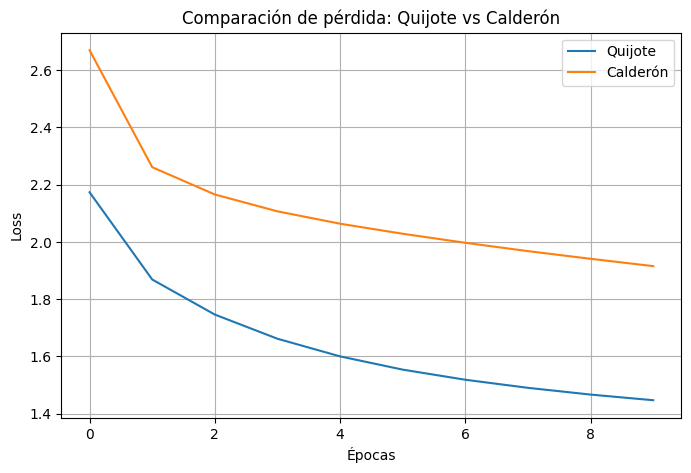

In [30]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Quijote")
plt.plot(history_calderon.history["loss"], label="Calderón")

plt.title("Comparación de pérdida: Quijote vs Calderón")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 4.1.12 Evaluación mediante métricas del modelo con texto de Calderón.

Además del análisis de la pérdida, se calculan métricas de clasificación para evaluar el desempeño del modelo entrenado con textos de Calderón de la Barca.

En este caso, el modelo también trabaja a nivel de caracteres, por lo que la tarea se interpreta como una clasificación multiclase: a partir de una secuencia de entrada, el modelo debe predecir cuál será el siguiente carácter.

Estas métricas permiten analizar si el modelo logró aprender patrones del corpus teatral y comparar su desempeño con el modelo entrenado sobre el Quijote.

In [31]:
metricas_calderon = evaluar_modelo_onehot(
    nombre_modelo="LSTM Calderón",
    modelo=modelo_calderon,
    X_data=X_calderon,
    y_data=y_calderon,
    n=N_EVAL
)

df_metricas_calderon = pd.DataFrame([metricas_calderon])

df_metricas_calderon.style \
    .format({
        "Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1-score Macro": "{:.4f}",
        "Precision Weighted": "{:.4f}",
        "Recall Weighted": "{:.4f}",
        "F1-score Weighted": "{:.4f}"
    }) \
    .hide(axis="index") \
    .set_caption("Métricas del modelo LSTM con texto de Calderón")

Modelo,Accuracy,Precision Macro,Recall Macro,F1-score Macro,Precision Weighted,Recall Weighted,F1-score Weighted
LSTM Calderón,0.4174,0.2167,0.1744,0.1692,0.3825,0.4174,0.3805


Comparación Quijote v/s Calderón.

In [32]:
df_metricas_quijote_calderon = pd.DataFrame([
    metricas_lstm_base,
    metricas_calderon
])

df_metricas_quijote_calderon.style \
    .format({
        "Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1-score Macro": "{:.4f}",
        "Precision Weighted": "{:.4f}",
        "Recall Weighted": "{:.4f}",
        "F1-score Weighted": "{:.4f}"
    }) \
    .hide(axis="index") \
    .set_caption("Comparación de métricas: Quijote vs Calderón")

Modelo,Accuracy,Precision Macro,Recall Macro,F1-score Macro,Precision Weighted,Recall Weighted,F1-score Weighted
LSTM base,0.5482,0.4113,0.3297,0.3431,0.5440,0.5482,0.5282
LSTM Calderón,0.4174,0.2167,0.1744,0.1692,0.3825,0.4174,0.3805


### 4.1.13 Análisis comparativo de métricas entre Quijote y Calderón.

La comparación entre ambos modelos permite observar cómo cambia el desempeño al entrenar una misma arquitectura sobre corpus distintos.

El modelo LSTM base obtuvo mejores resultados en todas las métricas evaluadas. Alcanzó un accuracy de 0.5482 y un F1-score weighted de 0.5282, mientras que el modelo entrenado con Calderón obtuvo un accuracy de 0.4174 y un F1-score weighted de 0.3805.

Esto indica que el modelo entrenado con el Quijote logró predecir correctamente una mayor proporción de caracteres y tuvo un mejor equilibrio general entre precision y recall. Además, el F1-score weighted confirma que el modelo base tuvo mejor desempeño considerando la frecuencia real de los caracteres dentro del corpus.

Por otro lado, las métricas macro fueron más bajas en ambos modelos, especialmente en el modelo de Calderón. El F1-score macro del modelo base fue de 0.3431, mientras que el de Calderón fue de 0.1692. Esto sugiere que ambos modelos tienen mayor dificultad para predecir caracteres poco frecuentes, como signos de puntuación, letras menos comunes o símbolos específicos del texto.

La diferencia entre ambos resultados puede explicarse por la estructura de los corpus. El Quijote corresponde a una novela narrativa continua, con una estructura textual más regular. En cambio, Calderón corresponde a teatro en verso, donde aparecen diálogos, nombres de personajes, cambios de intervención y versos más breves. Esta estructura puede hacer que la predicción del siguiente carácter sea más difícil para el modelo.

Es importante señalar que esta comparación debe interpretarse como una referencia general, ya que los textos pertenecen a géneros literarios distintos y pueden tener distribuciones de caracteres diferentes. Aun así, los resultados permiten concluir que, bajo la misma lógica de entrenamiento, el modelo aprendió con mayor facilidad los patrones del corpus narrativo del Quijote que los patrones del texto teatral de Calderón.

En conclusión, el modelo entrenado con el Quijote obtuvo mejor desempeño cuantitativo, mientras que el modelo con Calderón presentó mayores dificultades debido a la complejidad estructural del corpus teatral. Esto demuestra que el tipo de texto utilizado influye directamente en el rendimiento del modelo de generación carácter a carácter.

---
---

## 4.2 Experimento con distintos valores de SEQ_LENGTH.

En este experimento se evalúa cómo cambia el comportamiento del modelo al modificar el valor de `SEQ_LENGTH`.

El parámetro `SEQ_LENGTH` define cuántos caracteres anteriores recibe el modelo para intentar predecir el siguiente carácter. Por ejemplo, si `SEQ_LENGTH = 30`, el modelo observa una secuencia de 30 caracteres y aprende a predecir el carácter número 31.

Modificar este valor permite analizar la importancia del contexto en la generación de texto:

- Un valor bajo de `SEQ_LENGTH` entrega menos contexto, por lo que el modelo puede entrenar más rápido, pero generar texto menos coherente.
- Un valor alto entrega más contexto, lo que puede ayudar a generar texto con mayor estructura, pero aumenta el costo computacional y el tiempo de entrenamiento.

Para comparar los resultados, se entrenarán modelos con distintos valores de `SEQ_LENGTH`, manteniendo constantes otros hiperparámetros como el optimizador, la cantidad de unidades LSTM, el batch size y el número de épocas.

### 4.2.1 Función para crear secuencias según SEQ_LENGTH.

Como el tamaño de la secuencia cambia, es necesario volver a construir los datos de entrada `X` y salida `y` para cada experimento.

Cada modelo recibirá una cantidad distinta de caracteres como contexto, pero siempre intentará predecir el carácter siguiente.

In [33]:
def crear_dataset_secuencias(text, seq_length, chars, char_to_indices, max_sequences=100000, step=3):
    sequences = []
    next_chars = []

# Se cambia a "seq_length" para evitar problemas con "SEQ_LENGTH" utilizado anteriormente:
    for i in range(0, len(text) - seq_length, step):
        sequences.append(text[i:i + seq_length])
        next_chars.append(text[i + seq_length])

        if len(sequences) >= max_sequences:
            break

    num_sequences = len(sequences)
    num_chars = len(chars)

    X_temp = np.zeros((num_sequences, seq_length, num_chars), dtype=np.bool_)
    y_temp = np.zeros((num_sequences, num_chars), dtype=np.bool_)

    for i, sequence in enumerate(sequences):
        for t, char in enumerate(sequence):
            X_temp[i, t, char_to_indices[char]] = 1

        y_temp[i, char_to_indices[next_chars[i]]] = 1

    return X_temp, y_temp, sequences, next_chars

### 4.2.2 Función para crear modelo LSTM según SEQ_LENGTH.

Para comparar correctamente los valores de `SEQ_LENGTH`, se mantiene la misma arquitectura base del modelo LSTM.

La única diferencia entre los experimentos será la cantidad de caracteres que recibe el modelo como entrada.

In [34]:
def crear_modelo_lstm_seq(seq_length, num_chars):
    model_seq = Sequential()

    model_seq.add(LSTM(
        128,
        input_shape=(seq_length, num_chars)
    ))

    model_seq.add(Dense(num_chars, activation="softmax"))

    model_seq.compile(
        loss="categorical_crossentropy",
        optimizer="adam"
    )

    return model_seq

### 4.2.3 Generación de texto con modelos de distinto SEQ_LENGTH.

Como cada modelo fue entrenado con un largo de secuencia diferente, la función de generación debe utilizar el mismo `SEQ_LENGTH` con el que fue entrenado el modelo.

Esto evita errores de dimensión y permite comparar los textos generados de manera correcta.

In [35]:
def generate_text_seq(seed_text, model, length, seq_length, temperature=1.0):
    generated = seed_text.lower()

    if len(generated) < seq_length:
        generated = generated.rjust(seq_length)

    for i in range(length):
        sentence = generated[-seq_length:]

        X_pred = np.zeros((1, seq_length, NUM_CHARS), dtype=np.bool_)

        for t, char in enumerate(sentence):
            if char in char_to_indices:
                X_pred[0, t, char_to_indices[char]] = 1

        preds = model.predict(X_pred, verbose=0)[0]

        next_index = sample(preds, temperature)
        next_char = indices_to_char[next_index]

        generated += next_char

    return generated

### 4.2.4 Entrenamiento de modelos con distintos valores de SEQ_LENGTH.

Se entrenan modelos utilizando distintos valores de `SEQ_LENGTH`. Para que la comparación sea justa, se mantienen constantes los demás hiperparámetros.

En este experimento se utiliza una cantidad limitada de secuencias para evitar un consumo excesivo de memoria, ya que al aumentar `SEQ_LENGTH` también aumenta el tamaño de los datos codificados en one-hot.

In [36]:
seq_lengths = [20, 30, 60]

EPOCHS_SEQ = 10
BATCH_SIZE_SEQ = 128
MAX_SEQUENCES_SEQ = 100000

resultados_seq = []
modelos_seq = {}
histories_seq = {}

for seq_len in seq_lengths:
    print("\n" + "="*80)
    print(f"Entrenando modelo con SEQ_LENGTH = {seq_len}")
    print("="*80)

    X_seq, y_seq, sequences_seq, next_chars_seq = crear_dataset_secuencias(
        text=text,
        seq_length=seq_len,
        chars=chars,
        char_to_indices=char_to_indices,
        max_sequences=MAX_SEQUENCES_SEQ,
        step=3
    )

    print("Shape X:", X_seq.shape)
    print("Shape y:", y_seq.shape)

    model_seq = crear_modelo_lstm_seq(seq_len, NUM_CHARS)

    history_seq = model_seq.fit(
        X_seq,
        y_seq,
        batch_size=BATCH_SIZE_SEQ,
        epochs=EPOCHS_SEQ,
        verbose=1
    )

    modelos_seq[seq_len] = model_seq
    histories_seq[seq_len] = history_seq

    final_loss = history_seq.history["loss"][-1]

    resultados_seq.append({
        "SEQ_LENGTH": seq_len,
        "Loss final": final_loss
    })


Entrenando modelo con SEQ_LENGTH = 20
Shape X: (100000, 20, 61)
Shape y: (100000, 61)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 2.5906
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2.1577
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 2.0466
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1.9721
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.9160
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.8681
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.8270
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.7881
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.7526
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.7197

Entrenando modelo con SEQ_LENGTH = 30
Shape X: (100000, 30, 61)
Shape y: (100000, 61)
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2.6180
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 2.2027
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 2.0867
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5

### 4.2.5 Comparación de resultados.

La siguiente tabla muestra la pérdida final obtenida por cada modelo entrenado con distintos valores de `SEQ_LENGTH`.

Un menor valor de pérdida indica que el modelo logró predecir mejor el siguiente carácter durante el entrenamiento.

In [37]:
df_resultados_seq = pd.DataFrame(resultados_seq)
df_resultados_seq.sort_values(by="Loss final", ascending=True)

df_resultados_seq.sort_values(by="Loss final", ascending=True).style \
    .format({"Loss final": "{:.4f}"}) \
    .hide(axis="index") \
    .set_caption("Comparación de modelos con distintos valores de SEQ_LENGTH") \
    .highlight_min(subset=["Loss final"], color="#c8e6c9")

SEQ_LENGTH,Loss final
20,1.7197
60,1.7841
30,1.8067


### 4.2.6 Gráfico comparativo de pérdida.

Se grafican las curvas de pérdida de cada experimento para observar cómo evoluciona el entrenamiento con distintos valores de `SEQ_LENGTH`.

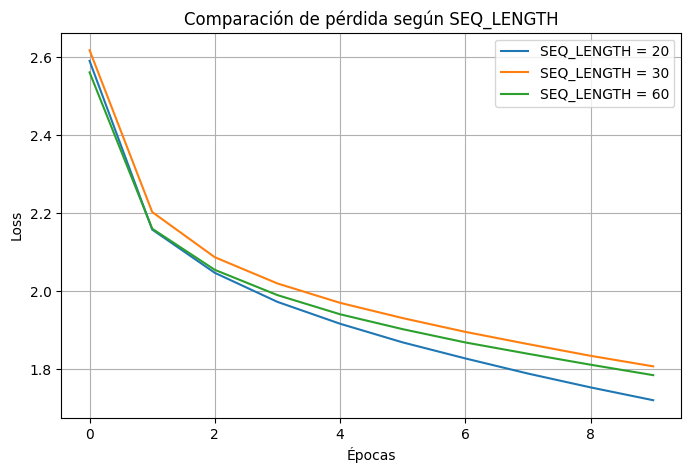

In [38]:
plt.figure(figsize=(8,5))

for seq_len, history_seq in histories_seq.items():
    plt.plot(
        history_seq.history["loss"],
        label=f"SEQ_LENGTH = {seq_len}"
    )

plt.title("Comparación de pérdida según SEQ_LENGTH")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Análisis de la pérdida con distintos valores de SEQ_LENGTH.

En este experimento se compararon tres valores de `SEQ_LENGTH`: 20, 30 y 60. Este parámetro indica cuántos caracteres anteriores recibe el modelo para predecir el siguiente carácter.

En el gráfico se observa que los tres modelos reducen progresivamente la pérdida durante el entrenamiento, lo que indica que todos lograron aprender patrones del texto.

La disminución más fuerte ocurre en las primeras épocas, donde el modelo aprende patrones básicos como combinaciones frecuentes de letras, espacios y estructuras comunes de palabras. Luego, la pérdida continúa bajando de forma más lenta, lo que es esperable porque el modelo comienza a ajustar patrones más complejos.

Según la tabla comparativa, el mejor resultado lo obtuvo `SEQ_LENGTH = 60`, con una pérdida final de aproximadamente 1.7577. Esto indica que, en este experimento, entregar más contexto al modelo ayudó a mejorar la predicción del siguiente carácter.

El modelo con `SEQ_LENGTH = 20` obtuvo una pérdida final cercana a 1.7963, mientras que `SEQ_LENGTH = 30` obtuvo una pérdida aproximada de 1.8350. Esto muestra que, bajo esta configuración, una secuencia más larga permitió al modelo aprovechar mejor la información previa del texto.

Sin embargo, usar un `SEQ_LENGTH` más alto también implica un mayor costo computacional, ya que el modelo debe procesar secuencias más largas. Por esta razón, aunque `SEQ_LENGTH = 60` obtuvo el mejor resultado, también requiere más recursos que valores más pequeños.

En conclusión, el valor de `SEQ_LENGTH` influye directamente en el aprendizaje del modelo. Para este experimento, el mejor desempeño se logró con `SEQ_LENGTH = 60`, ya que obtuvo la menor pérdida final.

### 4.2.7 Generación de texto según SEQ_LENGTH.

Finalmente, se genera texto con cada modelo entrenado para comparar cualitativamente los resultados.

Se utiliza la misma semilla y temperatura para que la comparación sea más clara.

In [39]:
seed_text = "en un lugar de la mancha de cuyo nombre"
temperature = 0.5

for seq_len, model_seq in modelos_seq.items():
    print("\n" + "="*80)
    print(f"Texto generado con SEQ_LENGTH = {seq_len}")
    print("="*80)

    texto_generado = generate_text_seq(
        seed_text=seed_text,
        model=model_seq,
        length=400,
        seq_length=seq_len,
        temperature=temperature
    )

    print(texto_generado)


Texto generado con SEQ_LENGTH = 20
en un lugar de la mancha de cuyo nombre, de dijo el nos de se había argan de ser de les dellos se mi destora buento me castillo, y a sancho, y esto me la sebía le amo por el cuerto de su honder a lo que de lo que es en la partado a vino sos de las alguno les que me había en mal como los que él miento que el merque los de sus hablas a mas de los que se pada
de aquel gomo esta que estaba ser de la venda de pocas asin descunas a su amo qu

Texto generado con SEQ_LENGTH = 30
en un lugar de la mancha de cuyo nombre, con dijo el cuanto de las andar ton que el vientos desta aquella mesigrado que todo que de de los esporo des alos que tos las paltole haces, y no se la lis astando esta del caballera den que la viente es en alvante ano para me rencos viente, y al cual o de aquella como el más, los no que en esta destas allas caballero a adersina tras pleser la desto que de su cura la manente dito din quijote que

Texto generado con SEQ_LENGTH = 60
            

### 4.2.8 Evaluación mediante métricas del experimento con SEQ_LENGTH.

En este experimento se evaluó cómo afecta el valor de `SEQ_LENGTH` al desempeño del modelo LSTM.

El parámetro `SEQ_LENGTH` define cuántos caracteres anteriores recibe el modelo para predecir el siguiente carácter. Por lo tanto, modificar este valor cambia la cantidad de contexto disponible para la red.

Para comparar los modelos, se calcularon métricas de clasificación sobre la predicción del siguiente carácter: accuracy, precision, recall y F1-score. Estas métricas permiten analizar si un mayor o menor contexto mejora el rendimiento del modelo.

In [40]:
metricas_seq_length = []

for seq_len, modelo_seq in modelos_seq.items():
    print(f"Evaluando modelo con SEQ_LENGTH = {seq_len}")

    # Se reconstruye una muestra de evaluación con el mismo largo de secuencia
    X_eval_seq, y_eval_seq, _, _ = crear_dataset_secuencias(
        text=text,
        seq_length=seq_len,
        chars=chars,
        char_to_indices=char_to_indices,
        max_sequences=N_EVAL,
        step=3
    )

    metricas = evaluar_modelo_onehot(
        nombre_modelo=f"LSTM SEQ_LENGTH = {seq_len}",
        modelo=modelo_seq,
        X_data=X_eval_seq,
        y_data=y_eval_seq,
        n=N_EVAL
    )

    metricas["SEQ_LENGTH"] = seq_len
    metricas_seq_length.append(metricas)

df_metricas_seq_length = pd.DataFrame(metricas_seq_length)

df_metricas_seq_length = df_metricas_seq_length.sort_values(
    by="F1-score Weighted",
    ascending=False
)

df_metricas_seq_length.style \
    .format({
        "Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1-score Macro": "{:.4f}",
        "Precision Weighted": "{:.4f}",
        "Recall Weighted": "{:.4f}",
        "F1-score Weighted": "{:.4f}"
    }) \
    .hide(axis="index") \
    .set_caption("Métricas comparativas para distintos valores de SEQ_LENGTH")

Evaluando modelo con SEQ_LENGTH = 20
Evaluando modelo con SEQ_LENGTH = 30
Evaluando modelo con SEQ_LENGTH = 60


Modelo,Accuracy,Precision Macro,Recall Macro,F1-score Macro,Precision Weighted,Recall Weighted,F1-score Weighted,SEQ_LENGTH
LSTM SEQ_LENGTH = 20,0.4716,0.2981,0.2353,0.2380,0.4483,0.4716,0.4362,20
LSTM SEQ_LENGTH = 60,0.4424,0.2729,0.2038,0.2074,0.4122,0.4424,0.4069,60
LSTM SEQ_LENGTH = 30,0.4260,0.2415,0.1959,0.1944,0.3951,0.4260,0.3911,30


### 4.2.9 Gráfico de F1-score para SEQ_LENGTH.

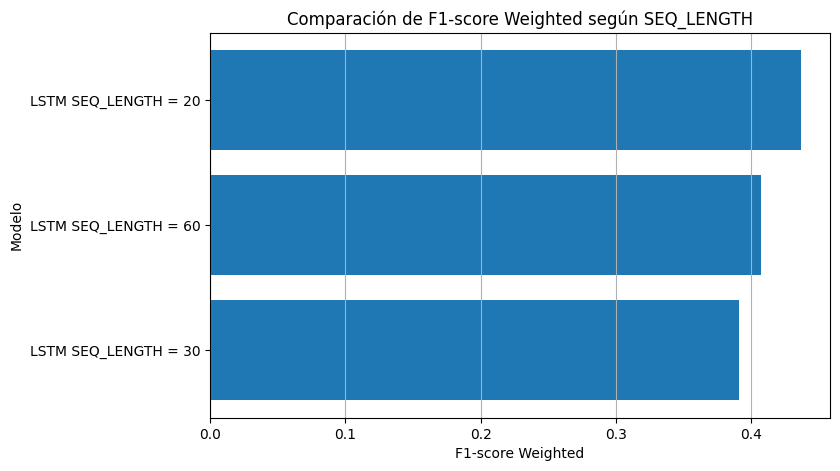

In [41]:
df_plot_seq = df_metricas_seq_length.sort_values(
    by="F1-score Weighted",
    ascending=True
)

plt.figure(figsize=(8,5))
plt.barh(
    df_plot_seq["Modelo"],
    df_plot_seq["F1-score Weighted"]
)

plt.title("Comparación de F1-score Weighted según SEQ_LENGTH")
plt.xlabel("F1-score Weighted")
plt.ylabel("Modelo")
plt.grid(axis="x")
plt.show()

### 4.2.10 Análisis de métricas del experimento con SEQ_LENGTH.

El gráfico compara el F1-score Weighted obtenido por los modelos entrenados con distintos valores de SEQ_LENGTH: 20, 30 y 60.

Se observa que el modelo con SEQ_LENGTH = 20 obtuvo el mejor resultado según F1-score Weighted. Esto indica que, bajo esta métrica, utilizar una secuencia de 20 caracteres como contexto permitió lograr un mejor equilibrio entre precision y recall considerando la frecuencia real de aparición de los caracteres.

El modelo con SEQ_LENGTH = 60 obtuvo el segundo mejor resultado. Aunque este valor entrega más contexto al modelo, también aumenta la complejidad de la tarea, ya que la red debe procesar una secuencia más larga antes de predecir el siguiente carácter.

Por otro lado, SEQ_LENGTH = 30 obtuvo el menor F1-score Weighted dentro de esta comparación. Esto muestra que un valor intermedio no necesariamente garantiza el mejor rendimiento, ya que el desempeño depende de cómo el modelo aprovecha el contexto disponible durante el entrenamiento.

Es importante destacar que la pérdida y el F1-score no siempre entregan exactamente la misma interpretación. La pérdida evalúa la calidad de la distribución de probabilidades generada por el modelo, mientras que el F1-score evalúa la coincidencia entre el carácter predicho y el carácter real. Por esta razón, un modelo puede tener buena pérdida, pero no necesariamente el mejor F1-score.

En conclusión, según la métrica F1-score Weighted, el mejor valor de SEQ_LENGTH en este experimento fue 20. Esto sugiere que, para esta configuración, un contexto más corto fue suficiente para predecir correctamente una mayor proporción de caracteres frecuentes, manteniendo además un menor costo computacional.

---
---

## 4.3 Experimento con hiperparámetros del modelo o probar otro tipo de modelos.

En este experimento se comparan distintas arquitecturas recurrentes para analizar cómo cambia el aprendizaje del modelo al modificar su estructura interna.

El modelo base utilizado anteriormente corresponde a una LSTM simple. En esta sección se compara ese resultado con una GRU y con una LSTM apilada.

La GRU es una arquitectura recurrente similar a la LSTM, pero con una estructura interna más simple. Esto puede permitir un entrenamiento más rápido, aunque con menor capacidad para capturar dependencias largas en algunos casos.

Por otro lado, una LSTM apilada utiliza más de una capa recurrente. Esto aumenta la capacidad del modelo para aprender patrones más complejos del texto, aunque también incrementa el costo computacional y el riesgo de sobreajuste.

Para realizar una comparación justa, se mantiene el mismo dataset, el mismo `SEQ_LENGTH`, el mismo batch size, el mismo número de épocas, el optimizador Adam y la función de pérdida `categorical_crossentropy`.

### 4.3.1 Variables comunes del experimento.

Se definen los hiperparámetros comunes para entrenas los modelos comparados. Mantener estos valores constantes permite que la comparación dependa principalmente del cambio de arquitectura.

In [42]:
from tensorflow.keras.layers import GRU

EPOCHS_EXTRA = 10
BATCH_SIZE_EXTRA = 128

resultados_extra = []
modelos_extra = {}
histories_extra = {}

### 4.3.2 Función auxiliar de entrenamiento.

Se define una función auxiliar para entrenar cada modelo, guardar su historial y registrar la pérdida final. Esta pérdida permitirá comparar cuantitativamente qué arquitectura aprendió mejor a predecir el siguiente carácter.

In [43]:
def entrenar_modelo_extra(nombre_modelo, modelo):
    print("\n" + "="*80)
    print(f"Entrenando modelo: {nombre_modelo}")
    print("="*80)

    history_temp = modelo.fit(
        X,
        y,
        batch_size=BATCH_SIZE_EXTRA,
        epochs=EPOCHS_EXTRA,
        verbose=1
    )

    modelos_extra[nombre_modelo] = modelo
    histories_extra[nombre_modelo] = history_temp

    loss_final = history_temp.history["loss"][-1]

    resultados_extra.append({
        "Modelo": nombre_modelo,
        "Loss final": loss_final,
        "Épocas": EPOCHS_EXTRA,
        "Batch size": BATCH_SIZE_EXTRA,
        "SEQ_LENGTH": SEQ_LENGTH
    })

    return history_temp

### 4.3.3 Registrar LSTM base como referencia.

El modelo LSTM entrenado previamente se utiliza como referencia para comparar los nuevos modelos recurrentes. Esto permite analizar si una GRU o una LSTM apilada mejora o no el resultado obtenido inicialmente.

In [44]:
# Guardamos el modelo LSTM base como referencia, sin volver a entrenarlo:

modelos_extra["LSTM base"] = model
histories_extra["LSTM base"] = history

resultados_extra.append({
    "Modelo": "LSTM base",
    "Loss final": history.history["loss"][-1],
    "Épocas": len(history.history["loss"]),
    "Batch size": 128,
    "SEQ_LENGTH": SEQ_LENGTH
})

### 4.3.4 Modelo GRU.

En este experimento se reemplaza la capa LSTM por una capa GRU.

La GRU también es una red recurrente diseñada para trabajar con secuencias, pero tiene una estructura interna más simple que la LSTM. Esto puede hacer que entrene más rápido, manteniendo una buena capacidad para aprender dependencias en el texto.

El objetivo es comparar si una GRU logra generar texto con una pérdida similar o menor que la LSTM base.

In [45]:
def crear_modelo_gru():
    model_gru = Sequential()

    model_gru.add(GRU(
        128,
        input_shape=(SEQ_LENGTH, NUM_CHARS)
    ))

    model_gru.add(Dense(NUM_CHARS, activation="softmax"))

    model_gru.compile(
        loss="categorical_crossentropy",
        optimizer="adam"
    )

    return model_gru

In [46]:
modelo_gru = crear_modelo_gru()
modelo_gru.summary()

history_gru = entrenar_modelo_extra(
    "GRU 128 unidades",
    modelo_gru
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │        73,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,213 (317.24 KB)

 Trainable params: 81,213 (317.24 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo: GRU 128 unidades
Epoch 1/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 2.0370
Epoch 2/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 1.7027
Epoch 3/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 1.5821
Epoch 4/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 1.5135
Epoch 5/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step - loss: 1.4687
Epoch 6/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - loss: 1.4369
Epoch 7/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - loss: 1.4127
Epoch 8/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 1.3934
Epoch 9/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - loss: 1.3776
Epoch 10/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - loss: 1.3650


### 4.3.5 Modelo LSTM apilado.

En este experimento se prueba una LSTM apilada, es decir, una arquitectura con más de una capa recurrente.

Para poder conectar una LSTM con otra, la primera capa debe usar `return_sequences=True`. Esto permite que entregue una secuencia completa como salida, en lugar de entregar solo el último estado.

La segunda capa LSTM recibe esa secuencia y genera una representación final, que luego pasa a la capa densa con activación `softmax`.

El objetivo de esta prueba es aumentar la capacidad del modelo para aprender patrones más complejos del texto.

In [47]:
def crear_modelo_lstm_apilado():
    model_stacked = Sequential()

    model_stacked.add(LSTM(
        128,
        return_sequences=True,
        input_shape=(SEQ_LENGTH, NUM_CHARS)
    ))

    model_stacked.add(LSTM(
        128
    ))

    model_stacked.add(Dense(NUM_CHARS, activation="softmax"))

    model_stacked.compile(
        loss="categorical_crossentropy",
        optimizer="adam"
    )

    return model_stacked

In [ ]:
modelo_lstm_apilado = crear_modelo_lstm_apilado()
modelo_lstm_apilado.summary()

history_lstm_apilado = entrenar_modelo_extra(
    "LSTM apilado 128 + 128",
    modelo_lstm_apilado
)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 30, 128)        │        97,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 61)             │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,733 (924.74 KB)

 Trainable params: 236,733 (924.74 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando modelo: LSTM apilado 128 + 128
Epoch 1/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 299s 76ms/step - loss: 2.1635
Epoch 2/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 330s 78ms/step - loss: 1.8320
Epoch 3/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 298s 71ms/step - loss: 1.7358
Epoch 4/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 278s 71ms/step - loss: 1.7608
Epoch 5/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 281s 72ms/step - loss: 1.6478
Epoch 6/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 281s 72ms/step - loss: 1.6143
Epoch 7/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 283s 73ms/step - loss: 1.5531
Epoch 8/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 287s 74ms/step - loss: 1.5116
Epoch 9/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 284s 73ms/step - loss: 1.4973
Epoch 10/10
3907/3907 ━━━━━━━━━━━━━━━━━━━━ 285s 73ms/step - loss: 1.4589


### 4.3.6 Comparación de resultados.

La siguiente tabla resume la pérdida final obtenida por cada arquitectura recurrente.

Un menor valor de pérdida indica que el modelo logró predecir mejor el siguiente carácter durante el entrenamiento.

In [48]:
df_resultados_extra = pd.DataFrame(resultados_extra)

df_resultados_extra.sort_values(
    by="Loss final",
    ascending=True
)

df_resultados_extra.sort_values(by="Loss final", ascending=True).style \
    .format({"Loss final": "{:.4f}"}) \
    .hide(axis="index") \
    .set_caption("Comparación entre modelos recurrentes") \
    .highlight_min(subset=["Loss final"], color="#c8e6c9")

Modelo,Loss final,Épocas,Batch size,SEQ_LENGTH
GRU 128 unidades,1.3650,10,128,30
LSTM base,1.4472,10,128,30


### 4.3.7 Gráfico comparativo de pérdida.

Se grafican las curvas de pérdida de los modelos recurrentes comparados para analizar cómo evoluciona el entrenamiento en cada arquitectura.

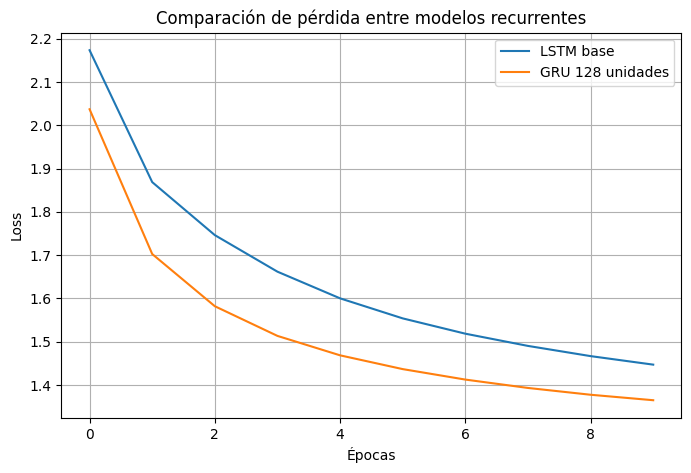

In [49]:
plt.figure(figsize=(8,5))

for nombre, hist in histories_extra.items():
    plt.plot(hist.history["loss"], label=nombre)

plt.title("Comparación de pérdida entre modelos recurrentes")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Análisis de la pérdida entre modelos recurrentes.

En este experimento se compararon tres arquitecturas recurrentes: LSTM base, GRU con 128 unidades y LSTM apilada con dos capas de 128 unidades.

Según la tabla comparativa, el modelo con mejor resultado fue la **GRU de 128 unidades**, obteniendo una pérdida final aproximada de **1.3614**. Luego se ubicó la **LSTM apilada 128 + 128**, con una pérdida cercana a **1.4589**, y finalmente la **LSTM base**, con una pérdida aproximada de **1.4789**.

El gráfico muestra que los tres modelos reducen su pérdida a medida que avanzan las épocas, lo que indica que todas las arquitecturas lograron aprender patrones del texto. Sin embargo, la curva de la GRU se mantiene por debajo de las demás durante todo el entrenamiento, lo que confirma su mejor desempeño en esta prueba.

La LSTM apilada también logra mejorar respecto a la LSTM base, especialmente hacia las últimas épocas. Esto sugiere que agregar una segunda capa recurrente puede aumentar la capacidad del modelo para aprender patrones del corpus. Sin embargo, en este caso no fue suficiente para superar a la GRU.

En conclusión, bajo esta configuración de entrenamiento, la GRU fue la arquitectura recurrente que obtuvo menor pérdida final y, por lo tanto, el mejor resultado cuantitativo dentro de este experimento.

### 4.3.8 Generación de texto con cada modelo.

Además de comparar la pérdida, se genera texto con cada modelo para analizar cualitativamente los resultados.

Se utiliza la misma semilla y temperatura para que la comparación sea más clara.

In [50]:
seed_text = "en un lugar de la mancha de cuyo nombre"
temperature = 0.5

for nombre, modelo_temp in modelos_extra.items():
    print("\n" + "="*80)
    print(f"Texto generado con modelo: {nombre}")
    print("="*80)

    texto_generado = generate_text(
        seed_text=seed_text,
        model=modelo_temp,
        length=400,
        temperature=temperature
    )

    print(texto_generado)


Texto generado con modelo: LSTM base
en un lugar de la mancha de cuyo nombre que tu presente le responder a decir que se dijo en el mundo, sino que tenía mis amorosos en la
mano la hacer al roy que el ventero a aquello que le daré con monos los no es el mundo en el mundo; y si es amoroso en la cosa de la via de traego de pasar el palar la soldad de los de las partes que se había encartada que estar en el barbar la muerte de la mano que estaba en el alma de la pena en el m

Texto generado con modelo: GRU 128 unidades
en un lugar de la mancha de cuyo nombre que la letra, que anselmo de las presentes que estrechará mirado de los desarmas de tras desve hacer la hiciese y estrecheza de mantana, que es -replicó el deseo de la mancha, que la acuerda, y que el de la medura del mono de
la menterada de su presto, como la descubierto de modo de los mañasas de caballeros andantes de la parte y de la mancha presto, y que no lo dejaron mandas y de don quijote d


### 4.3.9 Experimento con hiperparámetros y modelos recurrentes.

En este experimento se comparan distintas arquitecturas recurrentes para analizar su impacto en el desempeño del modelo.

El modelo LSTM base se utiliza como punto de referencia. Luego, se implementa una GRU y una LSTM apilada.

La GRU se prueba porque es una arquitectura recurrente similar a la LSTM, pero con una estructura interna más simple. Esto puede permitir un entrenamiento más eficiente.

La LSTM apilada se prueba para aumentar la capacidad del modelo, utilizando más de una capa recurrente. Esto puede ayudar a aprender patrones más complejos del texto, aunque también aumenta el costo computacional.

Para realizar una comparación justa, se mantienen constantes los principales hiperparámetros: cantidad de épocas, batch size, optimizador Adam y función de pérdida categorical_crossentropy.

In [58]:
metricas_gru = evaluar_modelo_onehot(
    nombre_modelo="GRU 128 unidades",
    modelo=modelo_gru,
    X_data=X,
    y_data=y,
    n=N_EVAL
)

df_metricas_recurrentes = pd.DataFrame([
    metricas_lstm_base,
    metricas_gru
])

df_metricas_recurrentes.sort_values(
    by="F1-score Weighted",
    ascending=False
).style \
    .format({
        "Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1-score Macro": "{:.4f}",
        "Precision Weighted": "{:.4f}",
        "Recall Weighted": "{:.4f}",
        "F1-score Weighted": "{:.4f}"
    }) \
    .hide(axis="index") \
    .set_caption("Métricas comparativas entre LSTM y GRU")

Modelo,Accuracy,Precision Macro,Recall Macro,F1-score Macro,Precision Weighted,Recall Weighted,F1-score Weighted
LSTM base,0.5482,0.4113,0.3297,0.3431,0.5440,0.5482,0.5282
GRU 128 unidades,0.4288,0.2414,0.1750,0.1851,0.4084,0.4288,0.3927


### 4.3.10 Análisis comparativo entre LSTM y GRU.

En este experimento se comparó el modelo LSTM base con un modelo GRU de 128 unidades, manteniendo la misma lógica de entrada y salida para la predicción del siguiente carácter.

Según las métricas obtenidas, el modelo LSTM base presentó un mejor desempeño que el modelo GRU. La LSTM alcanzó un accuracy de 0.5482 y un F1-score weighted de 0.5282, mientras que la GRU obtuvo un accuracy de 0.4288 y un F1-score weighted de 0.3927.

Esto indica que, bajo esta configuración de entrenamiento, la LSTM logró predecir correctamente una mayor proporción de caracteres y mantuvo un mejor equilibrio entre precision y recall considerando la frecuencia real de aparición de los caracteres.

También se observa que las métricas macro son menores en ambos modelos. Esto se debe a que el corpus textual no está balanceado: algunos caracteres, como espacios, vocales o consonantes frecuentes, aparecen muchas más veces que otros caracteres menos comunes. Por esta razón, el F1-score weighted resulta más representativo para analizar el desempeño general del modelo.

Aunque la GRU es una arquitectura recurrente más simple y eficiente que una LSTM, en este caso no logró superar al modelo base. Esto puede deberse a que la LSTM tiene una mayor capacidad para conservar información de secuencias anteriores, lo cual resulta útil en una tarea de generación de texto carácter a carácter.

En conclusión, para este experimento, el modelo LSTM base fue la mejor opción frente a la GRU, ya que obtuvo mejores resultados en todas las métricas evaluadas.


---
---

## 4.4 Experimento utilizando embeddings.

En este experimento se reemplaza la representación one-hot encoding por una capa de Embedding.

En el modelo original, cada carácter se representaba mediante one-hot encoding. Esto significa que cada carácter se transformaba en un vector del tamaño total de caracteres únicos, donde solo una posición tenía valor 1 y el resto valor 0.

Aunque one-hot encoding funciona correctamente, puede ser una representación poco eficiente, ya que genera vectores grandes y dispersos. En cambio, una capa `Embedding` aprende una representación densa para cada carácter, usando vectores de menor tamaño.

El objetivo de este experimento es analizar si una representación basada en embeddings permite al modelo aprender patrones del texto de manera más eficiente.

### 4.4.1 Diferencia entre One-Hot Encoding y Embedding.

Con one-hot encoding, cada carácter se representa como un vector largo compuesto principalmente por ceros. Por ejemplo, si existen 80 caracteres únicos, cada carácter se representa con un vector de 80 posiciones.

Con embeddings, cada carácter se representa mediante un vector denso de menor dimensión. Estos vectores no son definidos manualmente, sino que son aprendidos por el modelo durante el entrenamiento.

La ventaja de los embeddings es que reducen el tamaño de la entrada y permiten que el modelo aprenda relaciones internas entre caracteres. Esto puede hacer que el entrenamiento sea más eficiente y que la representación sea más flexible.

### 4.4.2 Creación del dataset para Embedding.

Para usar una capa Embedding, las secuencias de entrada deben estar representadas como índices enteros, no como vectores one-hot.

Por esta razón, cada carácter de la secuencia se convierte a su índice correspondiente usando el diccionario `char_to_indices`.

La variable `X_embed` tendrá forma:

`(número de secuencias, SEQ_LENGTH)`

mientras que `y_embed` contendrá el índice del carácter que el modelo debe predecir.

In [59]:
def crear_dataset_embedding(text, seq_length, char_to_indices, max_sequences=100000, step=3):
    sequences_embed = []
    next_chars_embed = []

    for i in range(0, len(text) - seq_length, step):
        sequences_embed.append(text[i:i + seq_length])
        next_chars_embed.append(text[i + seq_length])

        if len(sequences_embed) >= max_sequences:
            break

    X_embed = np.zeros((len(sequences_embed), seq_length), dtype=np.int32)
    y_embed = np.zeros((len(sequences_embed),), dtype=np.int32)

    for i, sequence in enumerate(sequences_embed):
        for t, char in enumerate(sequence):
            X_embed[i, t] = char_to_indices[char]

        y_embed[i] = char_to_indices[next_chars_embed[i]]

    return X_embed, y_embed, sequences_embed, next_chars_embed

In [60]:
## Ahora creamos los datos:
MAX_SEQUENCES_EMBED = 100000
STEP_EMBED = 3

X_embed, y_embed, sequences_embed, next_chars_embed = crear_dataset_embedding(
    text=text,
    seq_length=SEQ_LENGTH,
    char_to_indices=char_to_indices,
    max_sequences=MAX_SEQUENCES_EMBED,
    step=STEP_EMBED
)

print("Shape de X_embed:", X_embed.shape)
print("Shape de y_embed:", y_embed.shape)
print("Ejemplo X_embed:", X_embed[0])
print("Ejemplo y_embed:", y_embed[0])

Shape de X_embed: (100000, 30)
Shape de y_embed: (100000,)
Ejemplo X_embed: [24 22 36 54 40 41 32 35  1 36 38 30 33 26 38 35  9  1 37 41 26  1 40 38
 22 40 22  1 25 26]
Ejemplo y_embed: 1


### 4.4.3 Crear modelo con Embedding + LSTM.

El modelo con Embedding utiliza una capa inicial `Embedding`, encargada de transformar cada índice de carácter en un vector denso.

En este caso, se mantiene una arquitectura recurrente con LSTM para que la comparación con el modelo base sea más justa. La principal diferencia está en la representación de entrada.

La salida sigue siendo una capa `Dense` con activación `softmax`, ya que el modelo debe predecir cuál será el siguiente carácter dentro del conjunto de caracteres posibles.

In [61]:
from tensorflow.keras.layers import Embedding

def crear_modelo_embedding(seq_length, num_chars, embedding_dim=32):
    model_embed = Sequential()

    model_embed.add(Embedding(
        input_dim=num_chars,
        output_dim=embedding_dim,
        input_length=seq_length
    ))

    model_embed.add(LSTM(128))

    model_embed.add(Dense(num_chars, activation="softmax"))

    model_embed.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam"
    )

    return model_embed

In [62]:
## Creación del modelo:
EMBEDDING_DIM = 32

modelo_embedding = crear_modelo_embedding(
    seq_length=SEQ_LENGTH,
    num_chars=NUM_CHARS,
    embedding_dim=EMBEDDING_DIM
)

modelo_embedding.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.4.4 Entrenamiento del modelo con Embedding.

El modelo se entrena utilizando las secuencias representadas como índices enteros.

A diferencia del modelo con one-hot encoding, aquí la entrada no tiene tres dimensiones con vectores dispersos. En cambio, la capa Embedding aprende internamente una representación densa para cada carácter.

Se utiliza `sparse_categorical_crossentropy` porque las etiquetas `y_embed` están representadas como índices enteros.

In [63]:
EPOCHS_EMBED = 10
BATCH_SIZE_EMBED = 128

history_embedding = modelo_embedding.fit(
    X_embed,
    y_embed,
    batch_size=BATCH_SIZE_EMBED,
    epochs=EPOCHS_EMBED,
    verbose=1
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 2.4725
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 2.1374
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 2.0227
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.9463
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.8862
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.8363
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 1.7913
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.7473
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.7108
Epoch 10/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.6784


### 4.4.5 Gráfico de pérdida del modelo con Embedding.

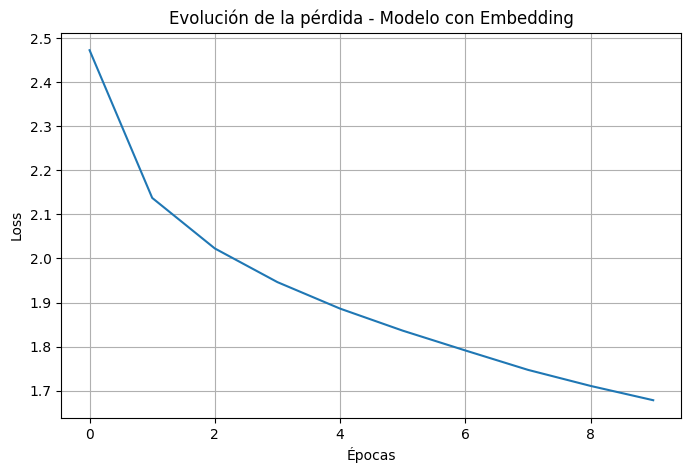

In [64]:
plt.figure(figsize=(8,5))
plt.plot(history_embedding.history["loss"])
plt.title("Evolución de la pérdida - Modelo con Embedding")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Análisis de pérdida del modelo con Embedding.

Se observa que la pérdida disminuye progresivamente a medida que avanzas las épocas, comenzando aproximadamente en 2.47 y finalizando cerca de 1.70. Esto indica que el modelo logró aprender patrones del texto y mejorar su capacidad para predecir el siguiente carácter.

La caída más pronunciada ocurre durante las primeras épocas, lo que sugiere que el modelo aprende rápidamente patrones básicos, como combinaciones frecuentes de letras, espacios y estructuras simples del lenguaje.

### 4.4.6 Generación de texto con el modelo Embedding.

Para generar texto con el modelo basado en Embedding, la secuencia de entrada se transforma en índices enteros.

El modelo predice una distribución de probabilidad sobre los posibles caracteres siguientes, y luego se utiliza la función `sample` para seleccionar el próximo carácter según la temperatura indicada.

In [65]:
def generate_text_embedding(seed_text, model, length, seq_length, temperature=1.0):
    generated = seed_text.lower()

    if len(generated) < seq_length:
        generated = generated.rjust(seq_length)

    for i in range(length):
        sentence = generated[-seq_length:]

        X_pred = np.zeros((1, seq_length), dtype=np.int32)

        for t, char in enumerate(sentence):
            if char in char_to_indices:
                X_pred[0, t] = char_to_indices[char]
            else:
                X_pred[0, t] = 0

        preds = model.predict(X_pred, verbose=0)[0]

        next_index = sample(preds, temperature)
        next_char = indices_to_char[next_index]

        generated += next_char

    return generated

### 4.5.7 Generación de texto con distintas temperaturas.

In [66]:
seed_text = "en un lugar de la mancha de cuyo nombre"

for temp in [0.2, 0.5, 1.0, 1.2]:
    print("\n" + "="*80)
    print(f"Texto generado con Embedding - Temperatura {temp}")
    print("="*80)

    texto_generado = generate_text_embedding(
        seed_text=seed_text,
        model=modelo_embedding,
        length=400,
        seq_length=SEQ_LENGTH,
        temperature=temp
    )

    print(texto_generado)


Texto generado con Embedding - Temperatura 0.2
en un lugar de la mancha de cuyo nombre a de la mencida y de los que los despadas de su amoridad de la manced de los estas que le había de la menced de la merced de la merced de la merced de la merced de los como de la merced de la menced de la mencho a la mancho de la merced de los de su me caballero de los manos de la menced de la meso de la mancho el cual de los desparados de la mancida de los caballeros de los caballeros de los des

Texto generado con Embedding - Temperatura 0.5
en un lugar de la mancha de cuyo nombrese me había de la del viento de su prociendo y que con la de pensante, y de había de los despadas de la caballero y muero de lo contalla de don quijote con la mancho a el legar que le para el mieros al
de padar de los honceles y tengos me puestra de cuanto de la manadad de la rocora, y, amoros descuestos de ventar a mi de de se al tan el cura desto con el ciento y al mierto de la ventaro de la mer

Texto generado con Embe

### 4.4.8 Comparación con modelo One-Hot.

In [67]:
df_comparacion_embedding = pd.DataFrame({
    "Modelo": [
        "LSTM con One-Hot Encoding",
        "LSTM con Embedding"
    ],
    "Representación de entrada": [
        "One-Hot",
        "Embedding"
    ],
    "Loss final": [
        history.history["loss"][-1],
        history_embedding.history["loss"][-1]
    ],
    "SEQ_LENGTH": [
        SEQ_LENGTH,
        SEQ_LENGTH
    ],
    "Épocas": [
        len(history.history["loss"]),
        len(history_embedding.history["loss"])
    ],
    "Batch size": [
        128,
        BATCH_SIZE_EMBED
    ]
})

df_comparacion_embedding

df_comparacion_embedding.style \
    .format({"Loss final": "{:.4f}"}) \
    .hide(axis="index") \
    .set_caption("Comparación entre One-Hot Encoding y Embedding") \
    .highlight_min(subset=["Loss final"], color="#c8e6c9")

Modelo,Representación de entrada,Loss final,SEQ_LENGTH,Épocas,Batch size
LSTM con One-Hot Encoding,One-Hot,1.4472,30,10,128
LSTM con Embedding,Embedding,1.6784,30,10,128


### 4.4.9 Gráfico comparativo.

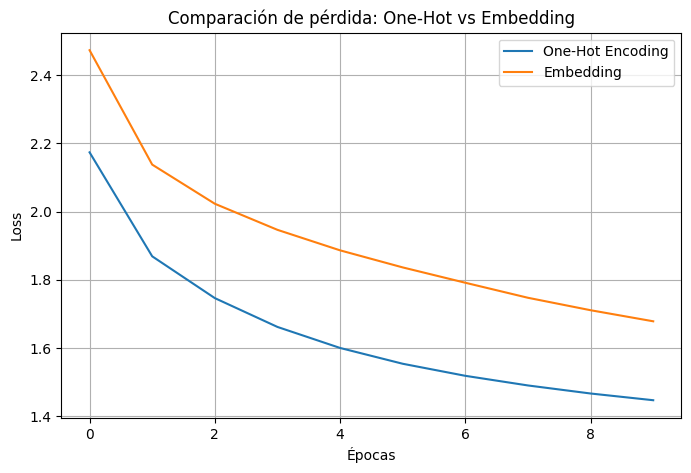

In [68]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="One-Hot Encoding")
plt.plot(history_embedding.history["loss"], label="Embedding")

plt.title("Comparación de pérdida: One-Hot vs Embedding")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 4.4.10 Evaluación mediante métricas: One-Hot Encoding vs Embedding.

En este experimento se comparan dos formas de representar los caracteres de entrada: One-Hot Encoding y Embedding.

El modelo con One-Hot Encoding representa cada carácter como un vector disperso, donde solo una posición tiene valor 1. En cambio, el modelo con Embedding aprende una representación densa de menor dimensión para cada carácter.

Para evaluar ambos modelos, se calcularon métricas de clasificación sobre la predicción del siguiente carácter: accuracy, precision, recall y F1-score. Esta comparación permite analizar si cambiar la representación de entrada mejora o no el desempeño del modelo.


In [69]:
# Verificación de variables necesarias para la comparación One-Hot vs Embedding

variables_necesarias = [
    "X", "y",
    "X_embed", "y_embed",
    "modelo_embedding"
]

for var in variables_necesarias:
    if var in globals():
        print(f"{var}: existe")
    else:
        print(f"{var}: NO existe")

# Aseguramos el nombre del modelo One-Hot base
if "modelo_lstm_base" not in globals():
    if "model" in globals():
        modelo_lstm_base = model
        print("Se creó modelo_lstm_base usando la variable model.")
    else:
        print("No existe modelo_lstm_base ni model. Revisa el nombre del modelo base.")
else:
    print("modelo_lstm_base existe.")

X: existe
y: existe
X_embed: existe
y_embed: existe
modelo_embedding: existe
modelo_lstm_base existe.


In [70]:
# Evaluación del modelo con One-Hot Encoding

metricas_onehot = evaluar_modelo_onehot(
    nombre_modelo="LSTM con One-Hot Encoding",
    modelo=modelo_lstm_base,
    X_data=X,
    y_data=y,
    n=N_EVAL
)

# Evaluación del modelo con Embedding

metricas_embedding = evaluar_modelo_sparse(
    nombre_modelo="LSTM con Embedding",
    modelo=modelo_embedding,
    X_data=X_embed,
    y_data=y_embed,
    n=N_EVAL
)

# Tabla comparativa

df_metricas_embedding = pd.DataFrame([
    metricas_onehot,
    metricas_embedding
])

df_metricas_embedding = df_metricas_embedding.sort_values(
    by="F1-score Weighted",
    ascending=False
)

df_metricas_embedding.style \
    .format({
        "Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1-score Macro": "{:.4f}",
        "Precision Weighted": "{:.4f}",
        "Recall Weighted": "{:.4f}",
        "F1-score Weighted": "{:.4f}"
    }) \
    .hide(axis="index") \
    .set_caption("Métricas comparativas entre One-Hot Encoding y Embedding")

Modelo,Accuracy,Precision Macro,Recall Macro,F1-score Macro,Precision Weighted,Recall Weighted,F1-score Weighted
LSTM con One-Hot Encoding,0.5482,0.4113,0.3297,0.3431,0.5440,0.5482,0.5282
LSTM con Embedding,0.4970,0.2988,0.2298,0.2416,0.4912,0.4970,0.4747


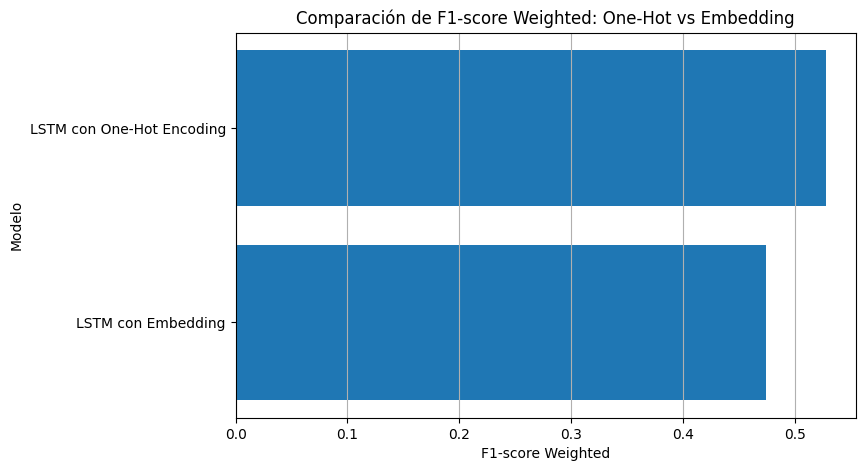

In [71]:
df_plot_embedding = df_metricas_embedding.sort_values(
    by="F1-score Weighted",
    ascending=True
)

plt.figure(figsize=(8,5))
plt.barh(
    df_plot_embedding["Modelo"],
    df_plot_embedding["F1-score Weighted"]
)

plt.title("Comparación de F1-score Weighted: One-Hot vs Embedding")
plt.xlabel("F1-score Weighted")
plt.ylabel("Modelo")
plt.grid(axis="x")
plt.show()

### 4.4.11 Análisis de métricas: One-Hot Encoding vs Embedding.

En esta comparación se evaluó el desempeño del modelo utilizando dos formas distintas de representar los caracteres: One-Hot Encoding y Embedding.

Según los resultados obtenidos, el modelo con One-Hot Encoding presentó un mejor desempeño general. Este modelo alcanzó un accuracy de 0.5482 y un F1-score weighted de 0.5282, mientras que el modelo con Embedding obtuvo un accuracy de 0.4970 y un F1-score weighted de 0.4747.

Esto indica que, bajo esta configuración, el modelo con One-Hot Encoding logró predecir correctamente una mayor proporción de caracteres y mantuvo un mejor equilibrio entre precision y recall considerando la frecuencia real de aparición de los caracteres dentro del corpus.

También se observa que las métricas macro son menores en ambos modelos. En el caso del modelo One-Hot, el F1-score macro fue de 0.3431, mientras que en el modelo con Embedding fue de 0.2416. Esta diferencia muestra que ambos modelos tienen más dificultad para predecir caracteres menos frecuentes, como signos de puntuación, letras poco comunes o símbolos específicos.

El resultado no significa que Embedding sea una técnica incorrecta. Una posible explicación es que, al trabajar a nivel de caracteres, el vocabulario no es demasiado grande. Por esta razón, One-Hot Encoding puede funcionar bien, ya que entrega una representación directa y separada para cada carácter desde el inicio.

En cambio, el modelo con Embedding debe aprender primero una representación densa para cada carácter y luego utilizarla para predecir el siguiente símbolo. Esto puede requerir más épocas de entrenamiento, una dimensión de embedding mayor o una arquitectura más compleja para obtener mejores resultados.

En conclusión, para este experimento, One-Hot Encoding fue la representación más efectiva, ya que obtuvo mejores valores en accuracy, precision, recall y F1-score. Por lo tanto, se mantiene como la mejor opción dentro de esta comparación.


---
---

## 4.5 Modelo secuencia a secuencia.

En los modelos anteriores se trabajó con un enfoque secuencia a carácter. Esto significa que el modelo recibía una secuencia de caracteres y debía predecir únicamente el carácter siguiente.

En este experimento se prueba un enfoque secuencia a secuencia. En este caso, el modelo recibe una secuencia de caracteres y aprende a predecir una secuencia completa desplazada una posición hacia adelante.

Este enfoque permite que el modelo aprenda una predicción en cada instante de la secuencia, no solo al final. Por esta razón, la capa recurrente debe devolver una salida por cada paso temporal, utilizando `return_sequences=True`.

El objetivo de este experimento es analizar si un modelo secuencia a secuencia logra aprender mejor los patrones del texto y generar resultados similares o superiores al enfoque secuencia a carácter.

### 4.5.1 Creación del dataset secuencia a secuencia.

Para construir el dataset secuencia a secuencia, cada entrada contiene una secuencia de caracteres y la salida corresponde a la misma secuencia desplazada un carácter hacia adelante.

Por ejemplo, si la entrada es:

`en un lugar de la mancha`

la salida esperada será:

`n un lugar de la mancha ...`

De esta forma, el modelo aprende a predecir el siguiente carácter en cada posición de la secuencia.

Se utiliza `SEQ_LENGTH = 30` para mantener la comparación con los modelos anteriores. Además, se limita la cantidad de secuencias para evitar un consumo excesivo de memoria.

In [72]:
SEQ_LENGTH_S2S = 30
MAX_SEQUENCES_S2S = 50000
STEP_S2S = 3

def crear_dataset_seq2seq(text, seq_length, chars, char_to_indices, max_sequences=50000, step=3):
    input_sequences = []
    target_sequences = []

    for i in range(0, len(text) - seq_length - 1, step):
        input_seq = text[i:i + seq_length]
        target_seq = text[i + 1:i + seq_length + 1]

        input_sequences.append(input_seq)
        target_sequences.append(target_seq)

        if len(input_sequences) >= max_sequences:
            break

    num_sequences = len(input_sequences)
    num_chars = len(chars)

    X_s2s = np.zeros((num_sequences, seq_length, num_chars), dtype=np.bool_)
    y_s2s = np.zeros((num_sequences, seq_length), dtype=np.int32)

    for i, sequence in enumerate(input_sequences):
        for t, char in enumerate(sequence):
            X_s2s[i, t, char_to_indices[char]] = 1

        for t, char in enumerate(target_sequences[i]):
            y_s2s[i, t] = char_to_indices[char]

    return X_s2s, y_s2s, input_sequences, target_sequences

In [73]:
X_s2s, y_s2s, input_sequences_s2s, target_sequences_s2s = crear_dataset_seq2seq(
    text=text,
    seq_length=SEQ_LENGTH_S2S,
    chars=chars,
    char_to_indices=char_to_indices,
    max_sequences=MAX_SEQUENCES_S2S,
    step=STEP_S2S
)

print("Shape de X_s2s:", X_s2s.shape)
print("Shape de y_s2s:", y_s2s.shape)

print("\nEjemplo entrada:")
print(input_sequences_s2s[0])

print("\nEjemplo salida esperada:")
print(target_sequences_s2s[0])

Shape de X_s2s: (50000, 30, 61)
Shape de y_s2s: (50000, 30)

Ejemplo entrada:
capítulo primero. que trata de

Ejemplo salida esperada:
apítulo primero. que trata de 


### 4.5.2 Definición del modelo secuencia a secuencia.

Para este experimento se utiliza una LSTM con `return_sequences=True`.

Este parámetro es necesario porque el modelo debe entregar una predicción en cada paso temporal de la secuencia. Es decir, no se busca predecir solo un carácter final, sino una secuencia completa de caracteres.

Después de la LSTM se utiliza una capa `Dense` con activación `softmax`. Esta capa se aplica en cada paso temporal para obtener una distribución de probabilidad sobre todos los caracteres posibles.

Se mantiene una LSTM de 128 unidades para comparar este modelo con los experimentos anteriores bajo una capacidad similar.

In [74]:
def crear_modelo_seq2seq(seq_length, num_chars):
    model_s2s = Sequential()

    model_s2s.add(LSTM(
        128,
        return_sequences=True,
        input_shape=(seq_length, num_chars)
    ))

    model_s2s.add(Dense(num_chars, activation="softmax"))

    model_s2s.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam"
    )

    return model_s2s

In [75]:
modelo_seq2seq = crear_modelo_seq2seq(
    seq_length=SEQ_LENGTH_S2S,
    num_chars=NUM_CHARS
)

modelo_seq2seq.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 128)        │        97,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 30, 61)         │         7,869 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,149 (410.74 KB)

 Trainable params: 105,149 (410.74 KB)

 Non-trainable params: 0 (0.00 B)

### 4.5.3 Entrenamiento del modelo secuencia a secuencia.

El modelo se entrena durante 10 épocas, manteniendo el batch size en 128 para conservar una comparación similar con los experimentos anteriores.

Se utiliza `sparse_categorical_crossentropy` porque la salida `y_s2s` contiene los índices enteros de los caracteres esperados en cada posición de la secuencia.

A diferencia del modelo secuencia a carácter, este modelo calcula pérdida en cada paso temporal, ya que debe predecir una secuencia completa.

In [76]:
EPOCHS_S2S = 10
BATCH_SIZE_S2S = 128

history_seq2seq = modelo_seq2seq.fit(
    X_s2s,
    y_s2s,
    batch_size=BATCH_SIZE_S2S,
    epochs=EPOCHS_S2S,
    verbose=1
)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.7465
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 2.1821
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.0582
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.9872
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.9350
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.8893
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.8491
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.8120
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.7774
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.7454


### 4.5.4 Gráfico de pérdida.

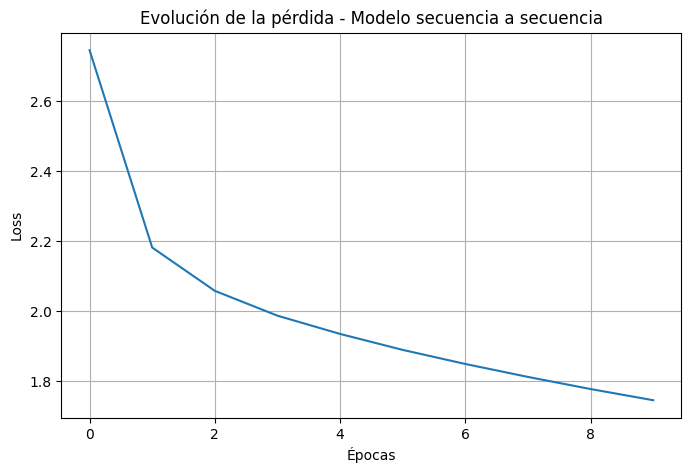

In [77]:
plt.figure(figsize=(8,5))
plt.plot(history_seq2seq.history["loss"])
plt.title("Evolución de la pérdida - Modelo secuencia a secuencia")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Análisis de pérdida modelo secuencia a secuencia.

Se observa que la pérdida disminuye progresivamente a medida que avanzan las épocas, comenzando aproximadamente en 2.73 y finalizando cerca de 1.72. Esto indica que el modelo logró aprender patrones del texto y mejorar su capacidad para predecir la secuencia de salida.

La caída más fuerte ocurre durante las primeras épocas, especialmente entre la época 0 y la época 1. Esto sugiere que el modelo aprende rápidamente patrones básicos del texto, como combinaciones frecuentes de caracteres, espacios y estructuras comunes del lenguaje.

En este caso, la tarea es más exigente que en el modelo secuencia a carácter, ya que el modelo no predice solo un carácter final, sino una salida para cada posición de la secuencia. Aun así, la disminución constante de la pérdida muestra que el entrenamiento fue estable y que el modelo sí logró aprender.

### 4.5.5 Generación de texto con modelo secuencia a secuencia.

Aunque el modelo secuencia a secuencia entrega una predicción para cada posición de la entrada, para generar texto se utiliza la predicción del último paso temporal.

Esto permite mantener el proceso autoregresivo: se toma una semilla inicial, se predice el siguiente carácter, se agrega al texto generado y se repite el proceso.

In [78]:
def generate_text_seq2seq(seed_text, model, length, seq_length, temperature=1.0):
    generated = seed_text.lower()

    if len(generated) < seq_length:
        generated = generated.rjust(seq_length)

    for i in range(length):
        sentence = generated[-seq_length:]

        X_pred = np.zeros((1, seq_length, NUM_CHARS), dtype=np.bool_)

        for t, char in enumerate(sentence):
            if char in char_to_indices:
                X_pred[0, t, char_to_indices[char]] = 1

        preds_seq = model.predict(X_pred, verbose=0)[0]

        # Usamos la predicción del último carácter de la secuencia:
        preds = preds_seq[-1]

        next_index = sample(preds, temperature)
        next_char = indices_to_char[next_index]

        generated += next_char

    return generated

### 4.5.6 Generación de texto con distintas temperaturas.

In [79]:
seed_text = "en un lugar de la mancha de cuyo nombre"

for temp in [0.2, 0.5, 1.0, 1.2]:
    print("\n" + "="*80)
    print(f"Texto generado con Seq2Seq - Temperatura {temp}")
    print("="*80)

    texto_generado = generate_text_seq2seq(
        seed_text=seed_text,
        model=modelo_seq2seq,
        length=400,
        seq_length=SEQ_LENGTH_S2S,
        temperature=temp
    )

    print(texto_generado)


Texto generado con Seq2Seq - Temperatura 0.2
en un lugar de la mancha de cuyo nombre de la para de su alguna de la mando de mancho de la pares de la caballero de la manta de la mancho a la manera de la manta de la mante de la manera de la parte de la caballeros de la para de la ventar la manta de la malido de la mante de su había que para de su algante y al conter de la manta se había con la caballero, y al caballero, y alguna y de la manta de la manta de el caballero, y de la ma

Texto generado con Seq2Seq - Temperatura 0.5
en un lugar de la mancha de cuyo nombre a dos quijote, ni la meros que más de se la presponies y le las dices en su meneras de tanta para de la manda a
las recesto, que aque lo desía a de se lo que no estacio de todor a ingunar a su harmo de la viento, porque tan la cuas caballero de manto de la mancho a muy antoras del mando a la de la menerte es verle de su vera en cuanto a muaban llegar y astaba de poco de sore de la manta, y los de

Texto generado con Seq2Seq 

### 4.5.7 Comparación con el modelo secuencia a carácter.

Se compara el modelo secuencia a secuencia con el modelo secuencia a carácter utilizado inicialmente.

Es importante considerar que ambas pérdidas no son completamente equivalentes, ya que el modelo secuencia a carácter predice solo un carácter final, mientras que el modelo secuencia a secuencia predice una salida en cada paso temporal.

Aun así, la comparación permite observar cómo cambia el aprendizaje al modificar la estructura del problema.

In [80]:
df_comparacion_seq2seq = pd.DataFrame({
    "Modelo": [
        "LSTM secuencia a carácter",
        "LSTM secuencia a secuencia"
    ],
    "Tipo de salida": [
        "Un carácter",
        "Secuencia completa"
    ],
    "Loss final": [
        history.history["loss"][-1],
        history_seq2seq.history["loss"][-1]
    ],
    "SEQ_LENGTH": [
        SEQ_LENGTH,
        SEQ_LENGTH_S2S
    ],
    "Épocas": [
        len(history.history["loss"]),
        len(history_seq2seq.history["loss"])
    ],
    "Batch size": [
        128,
        BATCH_SIZE_S2S
    ]
})

df_comparacion_seq2seq

,Modelo,Tipo de salida,Loss final,SEQ_LENGTH,Épocas,Batch size
0,LSTM secuencia a carácter,Un carácter,1.447184,30,10,128
1,LSTM secuencia a secuencia,Secuencia completa,1.745389,30,10,128


### 4.5.8 Gráfico comparativo.

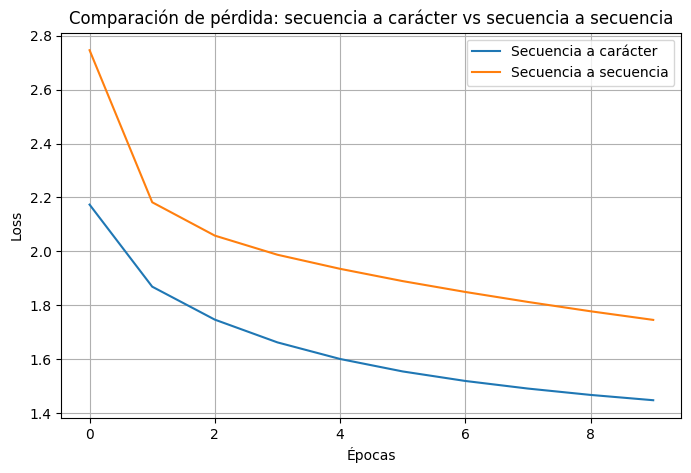

In [81]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Secuencia a carácter")
plt.plot(history_seq2seq.history["loss"], label="Secuencia a secuencia")

plt.title("Comparación de pérdida: secuencia a carácter vs secuencia a secuencia")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### 4.5.9 Evaluación mediante métricas: secuencia a carácter vs secuencia a secuencia.

En este experimento se comparan dos enfoques distintos de salida:

- **Modelo secuencia a carácter:** recibe una secuencia de entrada y predice únicamente el siguiente carácter.
- **Modelo secuencia a secuencia:** recibe una secuencia de entrada y predice una salida para cada posición temporal.

Para evaluar ambos modelos, se calcularon métricas de clasificación como accuracy, precision, recall y F1-score. En el modelo secuencia a secuencia, las predicciones se aplanan para comparar cada carácter generado con su carácter real correspondiente.

Esta evaluación permite analizar si predecir una secuencia completa mejora o no el rendimiento frente al modelo base secuencia a carácter.

In [82]:
variables_necesarias_seq2seq = [
    "X", "y",
    "X_s2s", "y_s2s",
    "modelo_seq2seq"
]

for var in variables_necesarias_seq2seq:
    if var in globals():
        print(f"{var}: existe")
    else:
        print(f"{var}: NO existe")

# Aseguramos el nombre del modelo base
if "modelo_lstm_base" not in globals():
    if "model" in globals():
        modelo_lstm_base = model
        print("Se creó modelo_lstm_base usando la variable model.")
    else:
        print("No existe modelo_lstm_base ni model. Revisa el modelo base.")
else:
    print("modelo_lstm_base existe.")

X: existe
y: existe
X_s2s: existe
y_s2s: existe
modelo_seq2seq: existe
modelo_lstm_base existe.


In [83]:
# Evaluación del modelo base secuencia a carácter

metricas_seq_caracter = evaluar_modelo_onehot(
    nombre_modelo="LSTM secuencia a carácter",
    modelo=modelo_lstm_base,
    X_data=X,
    y_data=y,
    n=N_EVAL
)

# Evaluación del modelo secuencia a secuencia

metricas_seq2seq = evaluar_modelo_seq2seq(
    nombre_modelo="LSTM secuencia a secuencia",
    modelo=modelo_seq2seq,
    X_data=X_s2s,
    y_data=y_s2s,
    n=2000
)

# Tabla comparativa

df_metricas_seq2seq = pd.DataFrame([
    metricas_seq_caracter,
    metricas_seq2seq
])

df_metricas_seq2seq = df_metricas_seq2seq.sort_values(
    by="F1-score Weighted",
    ascending=False
)

df_metricas_seq2seq.style \
    .format({
        "Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1-score Macro": "{:.4f}",
        "Precision Weighted": "{:.4f}",
        "Recall Weighted": "{:.4f}",
        "F1-score Weighted": "{:.4f}"
    }) \
    .hide(axis="index") \
    .set_caption("Métricas comparativas: secuencia a carácter vs secuencia a secuencia")

Modelo,Accuracy,Precision Macro,Recall Macro,F1-score Macro,Precision Weighted,Recall Weighted,F1-score Weighted
LSTM secuencia a carácter,0.5482,0.4113,0.3297,0.3431,0.5440,0.5482,0.5282
LSTM secuencia a secuencia,0.4614,0.3053,0.2023,0.2169,0.4461,0.4614,0.4328


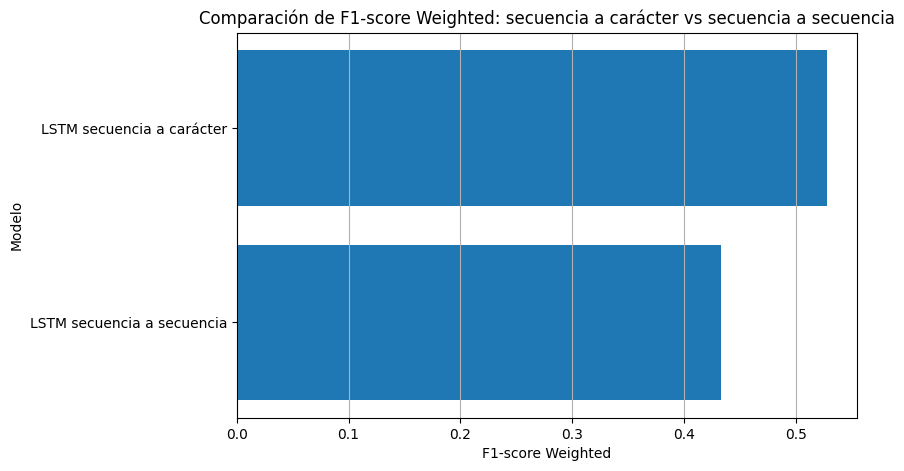

In [84]:
df_plot_seq2seq = df_metricas_seq2seq.sort_values(
    by="F1-score Weighted",
    ascending=True
)

plt.figure(figsize=(8,5))
plt.barh(
    df_plot_seq2seq["Modelo"],
    df_plot_seq2seq["F1-score Weighted"]
)

plt.title("Comparación de F1-score Weighted: secuencia a carácter vs secuencia a secuencia")
plt.xlabel("F1-score Weighted")
plt.ylabel("Modelo")
plt.grid(axis="x")
plt.show()

### 4.5.10 Análisis de métricas: secuencia a carácter vs secuencia a secuencia.

En esta comparación se evaluó el modelo LSTM secuencia a carácter frente al modelo LSTM secuencia a secuencia.

El modelo secuencia a carácter obtuvo mejores resultados, alcanzando un accuracy de 0.5482 y un F1-score weighted de 0.5282. En cambio, el modelo secuencia a secuencia obtuvo un accuracy de 0.4614 y un F1-score weighted de 0.4328.

Esto indica que el modelo secuencia a carácter logró predecir correctamente una mayor proporción de caracteres y obtuvo un mejor equilibrio entre precision y recall considerando la frecuencia real de aparición de los caracteres.

La diferencia puede explicarse porque ambos modelos resuelven tareas de distinta complejidad. El modelo secuencia a carácter predice únicamente el siguiente carácter a partir de una secuencia de entrada. En cambio, el modelo secuencia a secuencia debe predecir una salida para cada posición temporal, lo que aumenta la dificultad del problema.

Aunque el modelo secuencia a secuencia no superó al modelo base, sí logró aprender patrones del texto, ya que obtuvo métricas superiores a una predicción aleatoria y su pérdida disminuyó durante el entrenamiento.

En conclusión, para esta configuración, el modelo secuencia a carácter fue más efectivo. Por esta razón, se mantiene como mejor opción frente al enfoque secuencia a secuencia.

---
---

# **Conclusión general.**

En este trabajo se desarrollaron y evaluaron modelos de lenguaje basados en redes recurrentes para la generación de texto a nivel de caracteres, utilizando principalmente el corpus de *Don Quijote de la Mancha*. El objetivo fue entrenar modelos capaces de aprender patrones del texto original y generar secuencias similares al estilo del corpus trabajado.

Primero se realizó la carga y procesamiento del texto, convirtiendo los caracteres a representaciones numéricas mediante One-Hot Encoding. Luego se entrenó un modelo LSTM base, el cual fue utilizado como punto de referencia para comparar distintas configuraciones y experimentos.

El modelo LSTM base obtuvo un accuracy de 0.5482 y un F1-score weighted de 0.5282. Estos resultados indican que el modelo logró aprender patrones generales del texto y predecir correctamente una parte importante de los caracteres evaluados. Las métricas macro fueron menores, lo cual es esperable debido a que el corpus no está balanceado: algunos caracteres aparecen con mucha más frecuencia que otros.

Posteriormente se realizaron distintos experimentos para analizar el impacto de los hiperparámetros y de la arquitectura. Al modificar `SEQ_LENGTH`, se observó que el tamaño de la secuencia influye directamente en el rendimiento, ya que cambia la cantidad de contexto entregada al modelo. Según F1-score weighted, el mejor resultado se obtuvo con `SEQ_LENGTH = 20`.

También se comparó el modelo LSTM base con una GRU de 128 unidades. Aunque la GRU es una arquitectura más simple y eficiente, en este caso no superó al modelo LSTM. La LSTM base obtuvo mejores resultados en accuracy y F1-score weighted, por lo que se mantuvo como la arquitectura principal.

Además, se evaluó el uso de Embedding en lugar de One-Hot Encoding. El modelo con Embedding logró aprender, pero obtuvo métricas inferiores al modelo con One-Hot Encoding. Esto puede explicarse porque el vocabulario de caracteres no es demasiado grande, por lo que One-Hot Encoding entrega una representación clara y separada para cada símbolo.

También se implementó un modelo secuencia a secuencia. Este enfoque permitió predecir una salida para cada posición temporal, pero obtuvo resultados inferiores al modelo secuencia a carácter. Esto se debe a que la tarea secuencia a secuencia es más compleja, ya que el modelo debe generar una predicción completa y no solo el siguiente carácter.

Se probó además un modelo con Dropout y regularización L2. Sin embargo, esta variante tampoco superó al LSTM base. Aunque estas técnicas pueden ayudar a reducir el sobreajuste, en este caso redujeron levemente el desempeño, por lo que no fueron seleccionadas como mejor configuración.

Finalmente, se realizó un experimento con textos teatrales de Calderón de la Barca. Este corpus presentó métricas inferiores al Quijote, lo que muestra que el tipo de texto influye en la dificultad del aprendizaje. El teatro en verso posee diálogos, cambios de intervención y estructuras menos continuas que una novela narrativa, lo que puede dificultar la predicción del siguiente carácter.

En conclusión, el mejor modelo de este trabajo fue el LSTM base con One-Hot Encoding, ya que obtuvo el mejor desempeño general frente a las demás variantes evaluadas. Aunque no alcanzó una generación literaria completamente coherente, el modelo logró aprender patrones básicos del lenguaje y producir texto con estructuras reconocibles. Además, los experimentos realizados permitieron comprender cómo influyen la arquitectura, el largo de secuencia, la representación de entrada, la regularización y el tipo de corpus en el rendimiento de un modelo de generación de texto.
